# Construcción del conjunto de datos integrado

### Sistema Predictivo de Conducta Delictiva en la Ciudad de México
**Trabajo Final de Maestría — Equipo 1C — Entrega 2**

---

El presente cuaderno documenta la construcción del conjunto de datos que servirá de insumo al
análisis exploratorio y a la fase de modelado. El procedimiento sigue las especificaciones del
apartado 2.4 de la Entrega 1 —tratamiento de valores faltantes, corrección de inconsistencias,
integración, codificación y balanceo— y concluye con la estructura descrita en el apartado 2.5.

Las fuentes empleadas se encuentran en la carpeta `Entrega_2` y corresponden a los archivos
previamente seleccionados y verificados:

| Carpeta | Fuente | Función en el diseño |
|---|---|---|
| `01_EHRIIJ_personas_imputadas` | INEGI — Esquema Homologado de Recolección de Información de Impartición de Justicia, 2018-2021 | Clase positiva: personas imputadas por robo |
| `02_ENVIPE_poblacion_general` | INEGI — Encuesta Nacional de Victimización y Percepción sobre Seguridad Pública, 2018-2021 | Clase negativa: población general sin antecedentes registrados |
| `03_CDMX1_incidencia_FGJ` | Fiscalía General de Justicia de la CDMX — Carpetas de investigación | Contexto espacial y temporal por alcaldía |

**Nota sobre el alcance geográfico.** La verificación previa de completitud determinó que los
registros de la Ciudad de México en la EHRIIJ no reportan el bloque sociodemográfico. De las 60,385
personas imputadas por robo ante juzgados de la capital entre 2018 y 2021, ninguna presenta
completo el conjunto de siete variables de la Tabla 1, y la depuración que se documenta más
adelante retiene apenas medio millar con residencia declarada en la Ciudad de México. Por esa razón
la clase positiva se construye con cobertura nacional. El apartado 10 examina las consecuencias que
este patrón de cobertura impone sobre el uso de las variables territoriales.

## 1. Configuración del entorno

Se importan las bibliotecas requeridas y se fijan las rutas de trabajo y la semilla aleatoria,
esta última con el propósito de garantizar la reproducibilidad exacta de los resultados conforme
al apartado 3.6 de la Entrega 1.

In [40]:
%pip install pandas numpy scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [1]:
import csv
import re
import unicodedata
import warnings
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

SEMILLA = 42
np.random.seed(SEMILLA)

BASE = Path(r"C:\Users\canob\OneDrive\Documentos\Bases\Entrega_2")
DIR_EHRIIJ = BASE / "01_EHRIIJ_personas_imputadas"
DIR_ENVIPE = BASE / "02_ENVIPE_poblacion_general"
DIR_FGJ    = BASE / "03_CDMX1_incidencia_FGJ"
DIR_SALIDA = BASE / "04_dataset"
DIR_SALIDA.mkdir(exist_ok=True)

ANIOS = [2018, 2019, 2020, 2021]
EDAD_MIN, EDAD_MAX = 18, 70

print("Rutas verificadas:")
for d in (DIR_EHRIIJ, DIR_ENVIPE, DIR_FGJ):
    print(f"  {d.name:34s} existe={d.exists()}  archivos={len(list(d.rglob('*.*')))}")

Rutas verificadas:
  01_EHRIIJ_personas_imputadas       existe=True  archivos=48
  02_ENVIPE_poblacion_general        existe=True  archivos=99
  03_CDMX1_incidencia_FGJ            existe=True  archivos=2


## 2. Funciones auxiliares de lectura

Las fuentes del INEGI presentan tres particularidades que obligan a construir rutinas de lectura
específicas antes de cualquier tratamiento estadístico:

1. **Los nombres de las columnas cambian entre ejercicios y entre familias de tablas.** La variable
   de estado conyugal aparece como `edocivil` en 2018, `edo_civi` en los juzgados de control de
   2019 a 2021 y `estcivil` en el sistema tradicional; la escolaridad como `gdoestud`, `gd_estud` y
   `gra_estu`; el municipio de residencia como `muniresi`, `munresid` y `mureside`. Por ello la
   resolución de columnas se realiza mediante listas de candidatos.

2. **Un mismo código numérico designa categorías distintas según el archivo.** En el catálogo
   `gdoestud` de 2018 el código 8 corresponde a "No identificado", mientras que en `gd_estud` de
   2019 ese mismo código designa "Ninguno". En consecuencia, **la decodificación se efectúa
   siempre contra el catálogo incluido en cada archivo ZIP**, nunca contra una tabla de
   equivalencias fija.

3. **Los archivos de la ENVIPE de 2018 a 2021 emplean el retorno de carro como separador de
   registro y además lo incluyen dentro de cada campo entrecomillado.** La lectura se realiza con
   el módulo `csv` de la biblioteca estándar, que interpreta correctamente los saltos de línea
   contenidos en campos entrecomillados, seguida de la eliminación del carácter residual.

In [2]:
def normalizar(texto: str) -> str:
    '''Convierte una descripción de catálogo a minúsculas sin acentos ni espacios redundantes.'''
    t = unicodedata.normalize("NFKD", str(texto)).encode("ascii", "ignore").decode()
    return re.sub(r"\s+", " ", t).strip().lower()


def _decodificar(datos: bytes) -> str:
    for enc in ("utf-8-sig", "utf-8", "latin-1"):
        try:
            return datos.decode(enc)
        except UnicodeDecodeError:
            continue
    return datos.decode("latin-1", errors="replace")


def leer_tabla_zip(ruta_zip: Path) -> pd.DataFrame:
    '''Devuelve la tabla principal (carpeta conjunto_de_datos) de un ZIP de la EHRIIJ.'''
    with zipfile.ZipFile(ruta_zip) as zf:
        nombres = [n for n in zf.namelist()
                   if n.startswith("conjunto_de_datos/") and n.lower().endswith(".csv")]
        if not nombres:
            raise FileNotFoundError(f"Sin tabla principal en {ruta_zip.name}")
        texto = _decodificar(zf.read(nombres[0]))
    return pd.read_csv(io_texto(texto), dtype=str, low_memory=False)


def io_texto(texto: str):
    from io import StringIO
    return StringIO(texto)


def leer_catalogo_zip(ruta_zip: Path, columna: str) -> dict:
    '''Devuelve {código: descripción} del catálogo de una variable dentro de un ZIP.'''
    objetivo = f"catalogos/{columna}.csv"
    with zipfile.ZipFile(ruta_zip) as zf:
        if objetivo not in zf.namelist():
            return {}
        tabla = pd.read_csv(io_texto(_decodificar(zf.read(objetivo))), dtype=str)
    if tabla.shape[1] < 2:
        return {}
    codigos = tabla.iloc[:, 0].astype(str).str.strip()
    descrip = tabla.iloc[:, 1].astype(str).str.strip()
    return dict(zip(codigos, descrip))


def resolver_columna(columnas, candidatos):
    '''Devuelve el primer nombre de la lista de candidatos presente en el encabezado.'''
    for c in candidatos:
        if c in columnas:
            return c
    raise KeyError(f"Ninguno de {candidatos} está en {list(columnas)[:12]}...")


def leer_csv_con_retorno(ruta: Path) -> pd.DataFrame:
    '''Lee un CSV de la ENVIPE con retornos de carro incrustados en los campos.'''
    with open(ruta, newline="", encoding="utf-8-sig", errors="replace") as fh:
        filas = [[celda.strip() for celda in fila] for fila in csv.reader(fh)]
    encabezado = [c.strip() for c in filas[0]]
    ancho = len(encabezado)
    cuerpo = [f for f in filas[1:] if len(f) == ancho]
    descartadas = len(filas) - 1 - len(cuerpo)
    if descartadas:
        print(f"    {ruta.name}: {descartadas} filas con ancho irregular descartadas")
    return pd.DataFrame(cuerpo, columns=encabezado)


print("Funciones auxiliares definidas.")

Funciones auxiliares definidas.


## 3. Esquema común de variables

Se define el esquema al que deben converger ambas fuentes. Corresponde a las variables de la
Tabla 1 de la Entrega 1 que existen simultáneamente en la EHRIIJ y en la ENVIPE.

| Variable del esquema | Tipo | Valores |
|---|---|---|
| `sexo` | Nominal | H, M |
| `edad` | Numérica | 18 a 70 años |
| `nivel_instruccion` | Ordinal | 1 = Sin escolaridad · 2 = Primaria · 3 = Secundaria · 4 = Bachillerato · 5 = Profesional · 6 = Posgrado |
| `ocupacion` | Nominal | EA = económicamente activo · NEA = no económicamente activo |
| `cve_mun_residencia` | Nominal | Clave INEGI de cinco dígitos |
| `cve_ent_residencia` | Nominal | Clave INEGI de dos dígitos |
| `es_cdmx` | Binaria | 1 si reside en la Ciudad de México |
| `anio` | Numérica | Ejercicio de referencia |
| `clase` | Nominal | SI = procesado por robo · NO = grupo de contraste |

**Variables de la Tabla 1 que no forman parte del esquema común.** El estado conyugal y la
condición psicofísica se excluyen porque la ENVIPE no las capta: no se trata de un problema de
completitud, sino de que esas preguntas no figuran en el cuestionario. Ambas se conservan en el
conjunto exclusivo de la EHRIIJ para el análisis descriptivo del apartado 3.2.1.

La escolaridad se homologa **por la descripción textual del catálogo** y no por el código, dado
que las escalas difieren entre ejercicios.

In [4]:
# Reglas de equivalencia hacia la escala ordinal de la Tabla 1.
# El orden es significativo: se aplica la primera regla que coincide.
REGLAS_ESCOLARIDAD = [
    (r"^ningun",                                        1),
    (r"preescolar|primaria",                            2),
    (r"^secundaria",                                    3),
    (r"preparatoria|bachillerato|carrera tecnica|comercial|normal basica", 4),
    (r"licenciatura|profesional",                       5),
    (r"maestria|doctorado|posgrado",                    6),
]

ETIQUETA_ESCOLARIDAD = {
    1: "Sin escolaridad", 2: "Primaria", 3: "Secundaria",
    4: "Bachillerato", 5: "Profesional", 6: "Posgrado",
}

AUSENCIA = r"no identificado|no especificado|no aplica"


def escolaridad_desde_texto(descripcion):
    '''Traduce la descripción de catálogo a la escala ordinal de 1 a 6.'''
    if descripcion is None or (isinstance(descripcion, float) and np.isnan(descripcion)):
        return np.nan
    d = normalizar(descripcion)
    if not d or re.search(AUSENCIA, d):
        return np.nan
    for patron, valor in REGLAS_ESCOLARIDAD:
        if re.search(patron, d):
            return valor
    return np.nan


def ocupacion_desde_texto(descripcion):
    '''Traduce la ocupación de la EHRIIJ a la dicotomía EA / NEA.'''
    if descripcion is None or (isinstance(descripcion, float) and np.isnan(descripcion)):
        return np.nan
    d = normalizar(descripcion)
    if not d or re.search(AUSENCIA, d):
        return np.nan
    if "no ejercia" in d:
        return "NEA"
    return "EA"


# ENVIPE: condición de actividad. Se considera económicamente activa a la población
# ocupada (trabajó, tenía trabajo) y a la desocupada que buscó trabajo.
MAPA_ACTIVIDAD_ENVIPE = {
    "1": "EA", "2": "EA", "3": "EA",
    "4": "NEA", "5": "NEA", "6": "NEA", "7": "NEA", "8": "NEA",
}

COLUMNAS_ESQUEMA = [
    "sexo", "edad", "nivel_instruccion", "ocupacion",
    "cve_ent_residencia", "cve_mun_residencia", "es_cdmx", "anio", "clase",
]

print("Esquema común definido con", len(COLUMNAS_ESQUEMA), "columnas.")

Esquema común definido con 9 columnas.


## 4. Carga de la clase positiva (EHRIIJ)

La identificación de las personas imputadas por robo requiere el encadenamiento de tres tablas
por cada familia procesal y ejercicio:

1. **Tabla de delitos.** Se seleccionan los delitos de robo interrogando el catálogo `delirie*`
   propio de cada archivo y reteniendo los códigos cuya descripción corresponde al bien jurídico
   *patrimonio* y menciona el robo. Este criterio evita depender de rangos numéricos, que varían
   entre ejercicios, y excluye figuras ajenas al objeto de estudio como el robo de menor,
   clasificado bajo privación de la libertad.
2. **Tabla de enlace.** Vincula el delito con la persona mediante la llave
   `(ubicación geográfica, expediente, delito)`.
3. **Tabla de personas.** Aporta las variables sociodemográficas, decodificadas contra los
   catálogos del propio archivo.

Se procesan las tres familias procesales: juzgados de control (`jc`), juicio oral (`jo`) y sistema
tradicional (`ta`).

In [4]:
CANDIDATOS = {
    "sexo":    ["sexosnni"],
    "edad":    ["edades"],
    "civil":   ["estcivil", "edocivil", "edo_civi", "edociv"],
    "estudio": ["gra_estu", "gdoestud", "gd_estud", "gdo_estu"],
    "ocup":    ["tiocupac", "tip_ocup", "tipocupa"],
    "psic":    ["edo_psic", "edopsico"],
    "munres":  ["mureside", "muniresi", "munresid", "muresid"],
    "reinc":   ["reinctip", "reincide"],
}


def localizar(familia, anio, sufijo):
    patron = re.compile(rf"_{familia}_{sufijo}_ehriij{anio}_")
    encontrados = [p for p in DIR_EHRIIJ.glob("*.zip") if patron.search(p.name)]
    return encontrados[0] if len(encontrados) == 1 else None


def codigos_de_robo(ruta_delitos, columna_delito):
    '''Códigos del catálogo cuya descripción corresponde a un robo patrimonial.'''
    catalogo = leer_catalogo_zip(ruta_delitos, columna_delito)
    return {c for c, d in catalogo.items()
            if "robo" in normalizar(d) and "patrimonio" in normalizar(d)}


def cargar_bloque_ehriij(familia, anio):
    persona = "procesados" if familia == "ta" else "imputados"
    z_del = localizar(familia, anio, "delitos")
    z_lnk = localizar(familia, anio, f"{persona}_delito")
    z_per = localizar(familia, anio, persona)
    if not (z_del and z_lnk and z_per):
        print(f"  {familia}{anio}: archivos incompletos, se omite")
        return None

    delitos = leer_tabla_zip(z_del)
    col_geo_d = delitos.columns[0]
    col_del = next(c for c in delitos.columns if c.startswith("delirie"))
    robos = codigos_de_robo(z_del, col_del)
    delitos = delitos[delitos[col_del].astype(str).str.strip().isin(robos)]
    llave_delito = (delitos[col_geo_d].astype(str) + "|" +
                    delitos["cod_expe"].astype(str) + "|" +
                    delitos["cod_deli"].astype(str))
    del delitos

    enlace = leer_tabla_zip(z_lnk)
    col_geo_l = enlace.columns[0]
    clave_l = (enlace[col_geo_l].astype(str) + "|" +
               enlace["cod_expe"].astype(str) + "|" +
               enlace["cod_deli"].astype(str))
    enlace = enlace[clave_l.isin(set(llave_delito))]
    personas_robo = set(enlace[col_geo_l].astype(str) + "|" +
                        enlace["cod_expe"].astype(str) + "|" +
                        enlace["cod_proc"].astype(str))
    del enlace, llave_delito

    tabla = leer_tabla_zip(z_per)
    col_geo_p = tabla.columns[0]
    clave_p = (tabla[col_geo_p].astype(str) + "|" +
               tabla["cod_expe"].astype(str) + "|" +
               tabla["cod_proc"].astype(str))
    mascara = clave_p.isin(personas_robo)
    clave_p = clave_p[mascara]
    tabla = tabla[mascara].copy()
    if tabla.empty:
        return None

    cols = {k: resolver_columna(tabla.columns, v) for k, v in CANDIDATOS.items()}
    cat = {k: leer_catalogo_zip(z_per, c) for k, c in cols.items()}

    salida = pd.DataFrame(index=tabla.index)
    salida["id_origen"] = f"EHRIIJ|{familia}|{anio}|" + clave_p
    salida["sexo"] = tabla[cols["sexo"]].astype(str).str.strip().map({"1": "H", "2": "M"})
    salida["edad"] = pd.to_numeric(tabla[cols["edad"]], errors="coerce")
    salida["nivel_instruccion"] = (tabla[cols["estudio"]].astype(str).str.strip()
                                   .map(cat["estudio"]).map(escolaridad_desde_texto))
    salida["ocupacion"] = (tabla[cols["ocup"]].astype(str).str.strip()
                           .map(cat["ocup"]).map(ocupacion_desde_texto))
    salida["estado_conyugal"] = (tabla[cols["civil"]].astype(str).str.strip()
                                 .map(cat["civil"])
                                 .apply(lambda d: np.nan if d is None or not isinstance(d, str)
                                        or re.search(AUSENCIA, normalizar(d)) else d))
    salida["condicion_psicofisica"] = (tabla[cols["psic"]].astype(str).str.strip()
                                       .map(cat["psic"])
                                       .apply(lambda d: np.nan if d is None or not isinstance(d, str)
                                              or re.search(AUSENCIA, normalizar(d)) else d))
    mun = tabla[cols["munres"]].astype(str).str.strip().str.zfill(5)
    invalido = (~mun.str.fullmatch(r"\d{5}")) | mun.eq("00000") | mun.str.endswith("999")
    salida["cve_mun_residencia"] = mun.where(~invalido)
    salida["cve_ent_residencia"] = salida["cve_mun_residencia"].str[:2]
    salida["anio"] = anio
    salida["familia_procesal"] = familia
    salida["clase"] = "SI"
    return salida.reset_index(drop=True)


bloques = []
for anio in ANIOS:
    for familia in ("jc", "jo", "ta"):
        b = cargar_bloque_ehriij(familia, anio)
        if b is not None:
            bloques.append(b)
            print(f"  {familia}{anio}: {len(b):>7,} personas imputadas por robo")

positiva_cruda = pd.concat(bloques, ignore_index=True)
del bloques
print(f"\nClase positiva (registros crudos): {len(positiva_cruda):,}")

  jc2018:  57,474 personas imputadas por robo
  jo2018:   9,399 personas imputadas por robo
  ta2018:  15,329 personas imputadas por robo
  jc2019:  63,626 personas imputadas por robo
  jo2019:   8,833 personas imputadas por robo
  ta2019:  15,702 personas imputadas por robo
  jc2020:  84,882 personas imputadas por robo
  jo2020:   8,857 personas imputadas por robo
  ta2020:  13,688 personas imputadas por robo
  jc2021:  80,692 personas imputadas por robo
  jo2021:   9,643 personas imputadas por robo
  ta2021:  13,004 personas imputadas por robo

Clase positiva (registros crudos): 381,129


## 5. Carga de la clase negativa (ENVIPE)

La tabla sociodemográfica de la ENVIPE contiene una observación por integrante del hogar. Se
seleccionan las variables del esquema común y se aplica la homologación descrita en el apartado
anterior.

Cabe precisar que la ENVIPE registra la **condición de actividad** del informante, mientras que la
EHRIIJ registra el **tipo de ocupación**. Ambas se reducen a la dicotomía económicamente activo /
no económicamente activo para hacerlas comparables, si bien no constituyen constructos idénticos;
esta limitación se documenta en el apartado 2.6 del informe.

In [5]:
# Escala de nivel de instrucción de la ENVIPE hacia la escala ordinal de la Tabla 1.
MAPA_NIV_ENVIPE = {
    "00": 1,                        # Ninguno
    "01": 2, "02": 2,               # Preescolar, Primaria
    "03": 3,                        # Secundaria
    "04": 4, "05": 4, "06": 4, "07": 4,   # Media superior y carreras técnicas
    "08": 5,                        # Licenciatura o profesional
    "09": 6,                        # Posgrado
}


def cargar_envipe(anio):
    rutas = [p for p in DIR_ENVIPE.rglob("*.csv")
             if "conjunto_de_datos" in p.parts[-2].lower() and str(anio) in p.name]
    if not rutas:
        print(f"  ENVIPE {anio}: no localizada")
        return None
    tabla = leer_csv_con_retorno(rutas[0])
    tabla.columns = [c.upper() for c in tabla.columns]

    salida = pd.DataFrame(index=tabla.index)
    salida["id_origen"] = f"ENVIPE|{anio}|" + tabla["ID_PER"].astype(str).str.strip()
    salida["sexo"] = tabla["SEXO"].str.strip().map({"1": "H", "2": "M"})
    edad = pd.to_numeric(tabla["EDAD"], errors="coerce")
    salida["edad"] = edad.where(edad <= 97)          # 98 y 99 son códigos de no especificado
    salida["nivel_instruccion"] = tabla["NIV"].str.strip().str.zfill(2).map(MAPA_NIV_ENVIPE)
    salida["ocupacion"] = tabla["AP3_8"].str.strip().map(MAPA_ACTIVIDAD_ENVIPE)
    salida["estado_conyugal"] = np.nan            # no captada por la ENVIPE
    salida["condicion_psicofisica"] = np.nan      # no captada por la ENVIPE
    ent = tabla["CVE_ENT"].str.strip().str.zfill(2)
    mun = tabla["CVE_MUN"].str.strip().str.zfill(3)
    salida["cve_mun_residencia"] = (ent + mun).where(
        ent.str.fullmatch(r"\d{2}") & mun.str.fullmatch(r"\d{3}"))
    salida["cve_ent_residencia"] = ent.where(ent.str.fullmatch(r"\d{2}"))
    salida["anio"] = anio
    salida["familia_procesal"] = np.nan
    salida["clase"] = "NO"
    return salida.reset_index(drop=True)


bloques = []
for anio in ANIOS:
    b = cargar_envipe(anio)
    if b is not None:
        bloques.append(b)
        print(f"  ENVIPE {anio}: {len(b):>8,} personas")

negativa_cruda = pd.concat(bloques, ignore_index=True)
del bloques
print(f"\nClase negativa (registros crudos): {len(negativa_cruda):,}")

  ENVIPE 2018:  326,216 personas
  ENVIPE 2019:  325,381 personas
  ENVIPE 2020:  314,324 personas
  ENVIPE 2021:  318,419 personas

Clase negativa (registros crudos): 1,284,340


## 6. Contexto territorial (Fiscalía General de Justicia)

Las carpetas de investigación de la Fiscalía constituyen un registro de **hechos**, no de personas,
y carecen de llave que permita vincularlas con un individuo imputado. Por esa razón no se integran
al conjunto de entrenamiento, sino que se agregan por alcaldía y año para conformar una tabla de
contexto destinada al análisis exploratorio y al tablero ejecutivo, conforme al apartado 2.1.3 de
la Entrega 1.

In [6]:
fgj = pd.read_csv(DIR_FGJ / "carpetasFGJ_robo_2018_2021.csv", dtype=str, low_memory=False)
fgj["anio"] = pd.to_numeric(fgj["anio_hecho"].str.replace(r"\..*$", "", regex=True), errors="coerce")
fgj = fgj[fgj["anio"].between(min(ANIOS), max(ANIOS))]

contexto = (fgj.groupby(["alcaldia_hecho", "anio"])
              .size().reset_index(name="robos_registrados")
              .rename(columns={"alcaldia_hecho": "alcaldia"}))
contexto["anio"] = contexto["anio"].astype(int)
contexto = contexto[~contexto["alcaldia"].isin(["nan", "CDMX (indeterminada)"])]

print(f"Carpetas de robo consideradas: {len(fgj):,}")
print(f"Alcaldías identificadas: {contexto['alcaldia'].nunique()}")
display(contexto.pivot(index="alcaldia", columns="anio", values="robos_registrados")
                .sort_values(2021, ascending=False).head(10))

Carpetas de robo consideradas: 391,886
Alcaldías identificadas: 16


anio,2018,2019,2020,2021
alcaldia,,,,
IZTAPALAPA,19373,17213,12453,11839
CUAUHTEMOC,20363,15733,10469,11132
GUSTAVO A. MADERO,12413,10494,7806,7809
BENITO JUAREZ,12578,10353,7236,6816
COYOACAN,8156,6962,5826,6207
MIGUEL HIDALGO,9516,8518,5632,5628
ALVARO OBREGON,8061,7957,6047,5470
TLALPAN,5991,6066,4856,4836
AZCAPOTZALCO,6765,5063,4459,4640


## 7. Apartado 2.4.1 — Tratamiento de valores faltantes

Se analiza la completitud de cada variable en ambas fuentes por separado, dado que la naturaleza
de la ausencia difiere sustancialmente entre ellas.

In [7]:
def perfil_completitud(tabla, etiqueta):
    total = len(tabla)
    resumen = pd.DataFrame({
        "presentes": tabla.notna().sum(),
        "faltantes": tabla.isna().sum(),
    })
    resumen["% faltante"] = (resumen["faltantes"] / total * 100).round(1)
    resumen.insert(0, "fuente", etiqueta)
    return resumen


variables = ["sexo", "edad", "nivel_instruccion", "ocupacion",
             "estado_conyugal", "condicion_psicofisica",
             "cve_ent_residencia", "cve_mun_residencia"]

completitud = pd.concat([
    perfil_completitud(positiva_cruda[variables], "EHRIIJ (positiva)"),
    perfil_completitud(negativa_cruda[variables], "ENVIPE (negativa)"),
])
display(completitud)

,fuente,presentes,faltantes,% faltante
sexo,EHRIIJ (positiva),360677,20452,5.4
edad,EHRIIJ (positiva),381129,0,0.0
nivel_instruccion,EHRIIJ (positiva),130026,251103,65.9
ocupacion,EHRIIJ (positiva),78392,302737,79.4
estado_conyugal,EHRIIJ (positiva),252460,128669,33.8
condicion_psicofisica,EHRIIJ (positiva),125588,255541,67.0
cve_ent_residencia,EHRIIJ (positiva),175042,206087,54.1
cve_mun_residencia,EHRIIJ (positiva),175042,206087,54.1
sexo,ENVIPE (negativa),1284340,0,0.0
edad,ENVIPE (negativa),1276807,7533,0.6


### Criterio adoptado y su justificación

El apartado 2.4.1 de la Entrega 1 establece descartar las variables con más del 30% de valores
faltantes e imputar aquellas con menos del 5%. La aplicación literal de esa regla sobre el conjunto
integrado eliminaría el nivel de instrucción y la ocupación, que son precisamente las variables de
mayor interés teórico para el objetivo del proyecto.

Se adopta por tanto un criterio diferenciado, sustentado en la naturaleza del mecanismo de
ausencia:

- **La ausencia en la EHRIIJ no es aleatoria.** Obedece a que determinadas autoridades judiciales
  no reportan el bloque sociodemográfico, de modo que se trata de un patrón institucional
  sistemático. Imputar por moda en estas condiciones fabricaría precisamente la señal que el modelo
  pretende estimar, introduciendo un sesgo de magnitud desconocida.
- **La ausencia en la ENVIPE es marginal**, propia de la no respuesta puntual en una encuesta
  probabilística.

En consecuencia se aplica **eliminación por caso completo** sobre las variables del esquema común,
y se conserva registro del volumen resultante. El estado conyugal y la condición psicofísica no
participan de este filtro por no formar parte del esquema integrado.

In [8]:
esquema = ["sexo", "edad", "nivel_instruccion", "ocupacion", "cve_mun_residencia"]

antes_pos, antes_neg = len(positiva_cruda), len(negativa_cruda)
positiva = positiva_cruda.dropna(subset=esquema).copy()
negativa = negativa_cruda.dropna(subset=esquema).copy()

resumen_filtro = pd.DataFrame({
    "registros iniciales": [antes_pos, antes_neg],
    "casos completos":     [len(positiva), len(negativa)],
}, index=["EHRIIJ (positiva)", "ENVIPE (negativa)"])
resumen_filtro["% retenido"] = (resumen_filtro["casos completos"] /
                                resumen_filtro["registros iniciales"] * 100).round(1)
display(resumen_filtro)

crudos_cdmx = (positiva_cruda["cve_ent_residencia"] == "09").sum()
completos_cdmx = (positiva["cve_ent_residencia"] == "09").sum()
print(f"\nClase positiva con residencia declarada en CDMX")
print(f"  Antes del filtro de completitud : {crudos_cdmx:,}")
print(f"  Casos completos                 : {completos_cdmx:,} "
      f"({completos_cdmx / len(positiva) * 100:.1f}% de la clase positiva depurada)")
print("\nLa magnitud es marginal frente a las 60,385 personas imputadas por robo ante juzgados")
print("de la capital en el periodo, lo que confirma la verificación previa y sustenta el")
print("alcance nacional del estudio.")

,registros iniciales,casos completos,% retenido
EHRIIJ (positiva),381129,59957,15.7
ENVIPE (negativa),1284340,889707,69.3



Clase positiva con residencia declarada en CDMX
  Antes del filtro de completitud : 3,421
  Casos completos                 : 546 (0.9% de la clase positiva depurada)

La magnitud es marginal frente a las 60,385 personas imputadas por robo ante juzgados
de la capital en el periodo, lo que confirma la verificación previa y sustenta el
alcance nacional del estudio.


## 8. Apartado 2.4.2 — Corrección de inconsistencias

Se aplican reglas de validación derivadas del conocimiento del dominio y de las especificaciones
de la Tabla 1:

1. **Rango etario.** La Tabla 1 acota la edad al intervalo de 18 a 70 años. Los registros fuera de
   ese intervalo se excluyen, lo que además elimina a las personas menores de edad que pudieran
   haber quedado en la muestra.
2. **Validez de la clave territorial.** Se conservan únicamente las claves de entidad comprendidas
   entre 01 y 32.
3. **Dominio de las variables categóricas.** Se verifica que el sexo pertenezca a {H, M}, la
   ocupación a {EA, NEA} y el nivel de instrucción al intervalo entero de 1 a 6.
4. **Unicidad.** Se eliminan los registros duplicados conforme a la dimensión de unicidad
   establecida en el apartado 2.8.2. La verificación se realiza sobre el **identificador de origen**
   de cada registro —la llave `(ubicación, expediente, persona)` en la EHRIIJ y el identificador
   `ID_PER` en la ENVIPE— y no sobre la combinación de las variables del esquema.

   Esta precisión es determinante. Al reducirse el esquema a cinco variables de baja cardinalidad,
   un número elevado de personas distintas comparte necesariamente el mismo perfil: una mujer de 34
   años con secundaria, económicamente activa y residente en un mismo municipio no constituye un
   registro duplicado por coincidir con otra. Verificar la unicidad sobre las variables del esquema
   eliminaría más de 325,000 observaciones legítimas y sesgaría la distribución al conservar
   únicamente una persona por combinación posible.

In [9]:
def aplicar_validaciones(tabla, etiqueta):
    bitacora, n = [], len(tabla)

    def registrar(motivo, mascara):
        nonlocal tabla
        eliminados = int((~mascara).sum())
        bitacora.append({"fuente": etiqueta, "regla": motivo, "registros eliminados": eliminados})
        tabla = tabla[mascara]

    registrar("Edad fuera del rango 18-70", tabla["edad"].between(EDAD_MIN, EDAD_MAX))
    registrar("Clave de entidad inválida",
              tabla["cve_ent_residencia"].astype(str).str.fullmatch(r"0[1-9]|[12]\d|3[0-2]"))
    registrar("Sexo fuera de dominio", tabla["sexo"].isin(["H", "M"]))
    registrar("Ocupación fuera de dominio", tabla["ocupacion"].isin(["EA", "NEA"]))
    registrar("Nivel de instrucción fuera de dominio",
              tabla["nivel_instruccion"].between(1, 6))

    duplicados = int(tabla["id_origen"].duplicated().sum())
    tabla = tabla.drop_duplicates(subset="id_origen")
    bitacora.append({"fuente": etiqueta, "regla": "Registros duplicados (por identificador de origen)",
                     "registros eliminados": duplicados})
    print(f"{etiqueta}: {n:,} -> {len(tabla):,} registros")
    return tabla, bitacora


positiva, bit_pos = aplicar_validaciones(positiva, "EHRIIJ (positiva)")
negativa, bit_neg = aplicar_validaciones(negativa, "ENVIPE (negativa)")

bitacora_validacion = pd.DataFrame(bit_pos + bit_neg)
display(bitacora_validacion)

EHRIIJ (positiva): 59,957 -> 57,121 registros
ENVIPE (negativa): 889,707 -> 827,350 registros


,fuente,regla,registros eliminados
0,EHRIIJ (positiva),Edad fuera del rango 18-70,2836
1,EHRIIJ (positiva),Clave de entidad inválida,0
2,EHRIIJ (positiva),Sexo fuera de dominio,0
3,EHRIIJ (positiva),Ocupación fuera de dominio,0
4,EHRIIJ (positiva),Nivel de instrucción fuera de dominio,0
5,EHRIIJ (positiva),Registros duplicados (por identificador de ori...,0
6,ENVIPE (negativa),Edad fuera del rango 18-70,62357
7,ENVIPE (negativa),Clave de entidad inválida,0
8,ENVIPE (negativa),Sexo fuera de dominio,0
9,ENVIPE (negativa),Ocupación fuera de dominio,0


## 9. Apartado 2.4.3 — Integración de los conjuntos

Ambas fuentes se concatenan bajo el esquema común. La etiqueta de clase ya fue asignada en el
momento de la carga: **SI** para las personas imputadas por robo y **NO** para el grupo de
contraste. Se incorpora la variable `es_cdmx`, que permite conservar el foco territorial del
proyecto sin operar como filtro excluyente.

In [10]:
integrado = pd.concat([positiva, negativa], ignore_index=True)
integrado["es_cdmx"] = (integrado["cve_ent_residencia"] == "09").astype(int)
integrado["edad"] = integrado["edad"].astype(int)
integrado["nivel_instruccion"] = integrado["nivel_instruccion"].astype(int)
integrado["nivel_instruccion_etq"] = integrado["nivel_instruccion"].map(ETIQUETA_ESCOLARIDAD)

orden = ["id_origen", "clase", "sexo", "edad", "nivel_instruccion", "nivel_instruccion_etq",
         "ocupacion", "cve_ent_residencia", "cve_mun_residencia", "es_cdmx",
         "anio", "familia_procesal", "estado_conyugal", "condicion_psicofisica"]
integrado = integrado[orden]

print(f"Conjunto integrado: {len(integrado):,} registros x {integrado.shape[1]} columnas\n")
display(integrado["clase"].value_counts().rename("registros").to_frame()
        .assign(**{"%": lambda d: (d["registros"] / len(integrado) * 100).round(1)}))
display(integrado.head())

Conjunto integrado: 884,471 registros x 14 columnas



,registros,%
clase,,
NO,827350,93.5
SI,57121,6.5


,id_origen,clase,sexo,edad,nivel_instruccion,nivel_instruccion_etq,ocupacion,cve_ent_residencia,cve_mun_residencia,es_cdmx,anio,familia_procesal,estado_conyugal,condicion_psicofisica
0,EHRIIJ|jc|2018|03001|9920|11548,SI,H,35,2,Primaria,EA,03,03001,0,2018,jc,Soltero(a),En pleno uso de sus facultades mentales
1,EHRIIJ|jc|2018|03001|9952|11586,SI,H,39,1,Sin escolaridad,EA,03,03001,0,2018,jc,Unión Libre,En pleno uso de sus facultades mentales
2,EHRIIJ|jc|2018|03001|9956|11590,SI,H,37,3,Secundaria,EA,03,03001,0,2018,jc,Soltero(a),En pleno uso de sus facultades mentales
3,EHRIIJ|jc|2018|03001|9970|11606,SI,H,22,3,Secundaria,EA,03,03001,0,2018,jc,Soltero(a),En pleno uso de sus facultades mentales
4,EHRIIJ|jc|2018|03001|9973|11609,SI,H,36,2,Primaria,EA,03,03001,0,2018,jc,Soltero(a),En pleno uso de sus facultades mentales


## 10. Diagnóstico previo: sesgo de cobertura en las variables territoriales

Antes de construir la matriz de modelado se somete a examen la validez de las variables
territoriales como predictoras. La sospecha procede de una observación elemental: los juzgados de la
Ciudad de México atendieron a 60,385 personas imputadas por robo en el periodo, y sin embargo la
presencia de la capital en la clase positiva depurada resulta marginal.

La celda siguiente contrasta, para cada entidad federativa, su participación en el total de
personas imputadas por robo **antes** del filtro de completitud frente a su participación
**después** de dicho filtro.

In [11]:
antes = (positiva_cruda["cve_ent_residencia"].value_counts(normalize=True)
         .mul(100).rename("% antes del filtro"))
despues = (positiva["cve_ent_residencia"].value_counts(normalize=True)
           .mul(100).rename("% después del filtro"))

sesgo = pd.concat([antes, despues], axis=1).fillna(0)
sesgo["diferencia"] = (sesgo["% después del filtro"] - sesgo["% antes del filtro"]).round(1)
sesgo = sesgo.round(1).sort_values("diferencia")

print("Entidades más perjudicadas y más favorecidas por el filtro de completitud:\n")
display(pd.concat([sesgo.head(5), sesgo.tail(5)]))

print(f"\nCiudad de México (clave 09):")
print(f"  Participación antes del filtro : {sesgo.loc['09', '% antes del filtro']:.1f}%")
print(f"  Participación después del filtro: {sesgo.loc['09', '% después del filtro']:.1f}%")
print(f"\nProporción de residentes en CDMX por clase:")
display((pd.crosstab(integrado["clase"], integrado["es_cdmx"], normalize="index") * 100).round(1))

Entidades más perjudicadas y más favorecidas por el filtro de completitud:



,% antes del filtro,% después del filtro,diferencia
cve_ent_residencia,,,
15,19.3,5.0,-14.3
02,14.7,4.4,-10.3
11,10.0,2.2,-7.8
08,3.9,0.1,-3.8
09,2.0,0.9,-1.1
05,3.1,6.5,3.4
13,3.2,7.6,4.4
21,4.3,9.0,4.7
10,3.7,9.3,5.6



Ciudad de México (clave 09):
  Participación antes del filtro : 2.0%
  Participación después del filtro: 0.9%

Proporción de residentes en CDMX por clase:


es_cdmx,0,1
clase,,
NO,93.9,6.1
SI,99.1,0.9


### Interpretación y decisión metodológica

El contraste revela que la composición territorial de la clase positiva **no refleja la
distribución geográfica del delito, sino la propensión de cada autoridad judicial a reportar el
bloque sociodemográfico**. La Ciudad de México desaparece de la clase positiva pese a ser la
entidad con mayor número de personas imputadas por robo.

La clase negativa, en cambio, procede de una encuesta probabilística cuya distribución territorial
sí es representativa de la población. La consecuencia es directa: cualquier variable geográfica
introducida en el modelo permitiría separar ambas clases por un motivo espurio —qué entidades
reportan— y no por diferencias reales en el perfil de las personas. Un modelo así aprendería que
residir en la Ciudad de México reduce la probabilidad de ser imputado por robo, conclusión
manifiestamente falsa y atribuible por completo a un artefacto de registro.

En consecuencia se adopta el siguiente criterio:

- **La matriz de modelado excluye las variables territoriales.** Se conservan las cuatro variables
  personales del esquema común: sexo, edad, nivel de instrucción y ocupación.
- **Las claves territoriales permanecen en el conjunto analítico** para el análisis exploratorio
  descriptivo y para el tablero ejecutivo, donde su lectura es legítima siempre que se interprete
  como cobertura de registro y no como incidencia.
- Se genera adicionalmente una **matriz alternativa con geografía**, exclusivamente para
  documentar el efecto del sesgo en la comparación de modelos del apartado 3.2.3.

Esta limitación debe incorporarse al apartado 2.6 del informe.

## 11. Apartado 2.4.5 — Balanceo del conjunto

El apartado 2.5 de la Entrega 1 establece como objetivo una distribución del 30 al 40% de casos
positivos. Dado que la clase minoritaria dispone de un volumen considerable en términos absolutos,
se aplica **submuestreo aleatorio de la clase mayoritaria** en lugar de sobremuestreo sintético.

La preferencia por el submuestreo obedece a dos razones. En primer lugar, SMOTE genera
observaciones artificiales por interpolación, procedimiento poco apropiado cuando la totalidad de
las variables predictoras son categóricas o discretas. En segundo lugar, el volumen disponible de
la clase mayoritaria permite descartar observaciones sin comprometer la representatividad, de modo
que no existe necesidad de recurrir a datos sintéticos.

In [12]:
PROPORCION_POSITIVA = 0.35

pos = integrado[integrado["clase"] == "SI"]
neg = integrado[integrado["clase"] == "NO"]

n_neg_objetivo = int(round(len(pos) * (1 - PROPORCION_POSITIVA) / PROPORCION_POSITIVA))
n_neg_objetivo = min(n_neg_objetivo, len(neg))

neg_muestra = neg.sample(n=n_neg_objetivo, random_state=SEMILLA)
balanceado = (pd.concat([pos, neg_muestra], ignore_index=True)
                .sample(frac=1, random_state=SEMILLA)
                .reset_index(drop=True))

print(f"Clase positiva disponible : {len(pos):,}")
print(f"Clase negativa disponible : {len(neg):,}")
print(f"Clase negativa muestreada : {len(neg_muestra):,}")
print(f"Conjunto balanceado       : {len(balanceado):,}")
display(balanceado["clase"].value_counts(normalize=True).mul(100).round(1)
        .rename("% del total").to_frame())

Clase positiva disponible : 57,121
Clase negativa disponible : 827,350
Clase negativa muestreada : 106,082
Conjunto balanceado       : 163,203


,% del total
clase,
NO,65.0
SI,35.0


## 12. Apartado 2.4.4 — Codificación y normalización

Se construye la matriz destinada a los algoritmos de clasificación:

- **Sexo y ocupación**, de naturaleza nominal binaria, se codifican mediante *one-hot encoding* con
  supresión de la primera categoría para evitar la colinealidad perfecta.
- **Nivel de instrucción** conserva su codificación ordinal, pues el orden entre categorías es
  informativo y su tratamiento como nominal supondría descartar información.
- **Edad** se normaliza mediante escalado estándar (puntuación z), requerido por los algoritmos
  sensibles a la escala, tales como la red neuronal multicapa.
- **Las variables territoriales se excluyen** por el motivo expuesto en el apartado anterior.

La normalización se ajusta exclusivamente sobre la partición de entrenamiento y se aplica después a
la de prueba, con el objeto de evitar la filtración de información entre particiones. La partición
es estratificada, de modo que ambas conserven la proporción de clases del conjunto completo.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

PREDICTORAS = ["sexo", "edad", "nivel_instruccion", "ocupacion"]
TERRITORIALES = ["cve_ent_residencia", "es_cdmx"]

y = (balanceado["clase"] == "SI").astype(int)

def construir_matriz(columnas):
    M = balanceado[columnas].copy()
    nominales = [c for c in ("sexo", "ocupacion", "cve_ent_residencia") if c in M.columns]
    return pd.get_dummies(M, columns=nominales, drop_first=True, dtype=int)

X = construir_matriz(PREDICTORAS)                    # matriz principal
X_geo = construir_matriz(PREDICTORAS + TERRITORIALES)  # variante de diagnóstico

X_entrena, X_prueba, y_entrena, y_prueba = train_test_split(
    X, y, test_size=0.20, random_state=SEMILLA, stratify=y)

escalador = StandardScaler()
X_entrena = X_entrena.copy(); X_prueba = X_prueba.copy()
X_entrena["edad"] = escalador.fit_transform(X_entrena[["edad"]])
X_prueba["edad"] = escalador.transform(X_prueba[["edad"]])

print(f"Matriz principal          : {X.shape[1]} variables -> {list(X.columns)}")
print(f"Matriz con geografía      : {X_geo.shape[1]} variables (sólo para diagnóstico)")
print(f"Partición de entrenamiento: {len(X_entrena):,} registros ({y_entrena.mean():.1%} positivos)")
print(f"Partición de prueba       : {len(X_prueba):,} registros ({y_prueba.mean():.1%} positivos)")
print(f"\nEdad normalizada en entrenamiento — media {X_entrena['edad'].mean():+.4f}, "
      f"desviación {X_entrena['edad'].std():.4f}")
display(X_entrena.head())

Matriz principal          : 4 variables -> ['edad', 'nivel_instruccion', 'sexo_M', 'ocupacion_NEA']
Matriz con geografía      : 36 variables (sólo para diagnóstico)
Partición de entrenamiento: 130,562 registros (35.0% positivos)
Partición de prueba       : 32,641 registros (35.0% positivos)

Edad normalizada en entrenamiento — media +0.0000, desviación 1.0000


,edad,nivel_instruccion,sexo_M,ocupacion_NEA
152343,-1.360039,2,0,0
142241,-0.477019,3,0,0
162708,0.258831,3,1,0
44448,-1.212869,2,0,0
151032,-0.624189,2,0,0


## 13. Apartado 2.5 — Tamaño, estructura y exportación

Se exportan los productos resultantes en formato tabular, con una observación por fila y una
variable por columna, compatible con las bibliotecas de aprendizaje automático seleccionadas.

In [14]:
salidas = {
    "dataset_integrado_analitico.csv": integrado,
    "dataset_modelo_balanceado.csv":   balanceado,
    "X_entrenamiento.csv":             X_entrena.assign(clase=y_entrena.values),
    "X_prueba.csv":                    X_prueba.assign(clase=y_prueba.values),
    "X_variante_con_geografia.csv":    X_geo.assign(clase=y.values),
    "contexto_robo_alcaldia_anio.csv": contexto,
    "bitacora_validacion.csv":         bitacora_validacion,
    "completitud_por_fuente.csv":      completitud.reset_index(names="variable"),
    "sesgo_territorial.csv":           sesgo.reset_index(names="cve_ent"),
}
for nombre, tabla in salidas.items():
    tabla.to_csv(DIR_SALIDA / nombre, index=False, encoding="utf-8-sig")
    print(f"  {nombre:38s} {len(tabla):>8,} filas")

print(f"\nArchivos escritos en: {DIR_SALIDA}")

  dataset_integrado_analitico.csv         884,471 filas
  dataset_modelo_balanceado.csv           163,203 filas
  X_entrenamiento.csv                     130,562 filas
  X_prueba.csv                             32,641 filas
  X_variante_con_geografia.csv            163,203 filas
  contexto_robo_alcaldia_anio.csv              64 filas
  bitacora_validacion.csv                      12 filas
  completitud_por_fuente.csv                   16 filas
  sesgo_territorial.csv                        32 filas

Archivos escritos en: C:\Users\canob\OneDrive\Documentos\Bases\Entrega_2\04_dataset


### Diccionario del conjunto de datos

In [15]:
diccionario = pd.DataFrame([
    ("id_origen", "Texto", "Clave compuesta", "Identificador del registro en la fuente original; permite trazabilidad y verificación de unicidad"),
    ("clase", "Nominal", "SI / NO", "Variable objetivo. SI = persona imputada por robo; NO = grupo de contraste"),
    ("sexo", "Nominal", "H / M", "Sexo registrado de la persona"),
    ("edad", "Numérica", "18 a 70", "Edad en años cumplidos al momento del registro"),
    ("nivel_instruccion", "Ordinal", "1 a 6", "1 Sin escolaridad · 2 Primaria · 3 Secundaria · 4 Bachillerato · 5 Profesional · 6 Posgrado"),
    ("ocupacion", "Nominal", "EA / NEA", "Condición de actividad económica"),
    ("cve_ent_residencia", "Nominal", "01 a 32", "Clave INEGI de la entidad de residencia"),
    ("cve_mun_residencia", "Nominal", "5 dígitos", "Clave INEGI del municipio de residencia"),
    ("es_cdmx", "Binaria", "0 / 1", "Indica residencia en la Ciudad de México"),
    ("anio", "Numérica", "2018 a 2021", "Ejercicio de referencia del registro"),
    ("familia_procesal", "Nominal", "jc / jo / ta", "Familia procesal de origen; sólo aplica a la clase positiva"),
    ("estado_conyugal", "Nominal", "Texto", "Sólo disponible en la clase positiva; excluida del modelo integrado"),
    ("condicion_psicofisica", "Nominal", "Texto", "Sólo disponible en la clase positiva; excluida del modelo integrado"),
], columns=["variable", "tipo", "valores", "descripción"])

diccionario.to_csv(DIR_SALIDA / "diccionario_dataset.csv", index=False, encoding="utf-8-sig")
display(diccionario)

,variable,tipo,valores,descripción
0,id_origen,Texto,Clave compuesta,Identificador del registro en la fuente origin...
1,clase,Nominal,SI / NO,Variable objetivo. SI = persona imputada por r...
2,sexo,Nominal,H / M,Sexo registrado de la persona
3,edad,Numérica,18 a 70,Edad en años cumplidos al momento del registro
4,nivel_instruccion,Ordinal,1 a 6,1 Sin escolaridad · 2 Primaria · 3 Secundaria ...
5,ocupacion,Nominal,EA / NEA,Condición de actividad económica
6,cve_ent_residencia,Nominal,01 a 32,Clave INEGI de la entidad de residencia
7,cve_mun_residencia,Nominal,5 dígitos,Clave INEGI del municipio de residencia
8,es_cdmx,Binaria,0 / 1,Indica residencia en la Ciudad de México
9,anio,Numérica,2018 a 2021,Ejercicio de referencia del registro


## 14. Síntesis del procedimiento

La celda siguiente consolida las cifras del proceso para su incorporación directa al apartado 2.5
del informe.

In [16]:
sintesis = pd.DataFrame([
    ("Registros crudos, clase positiva (EHRIIJ)", f"{antes_pos:,}"),
    ("Registros crudos, clase negativa (ENVIPE)", f"{antes_neg:,}"),
    ("Casos completos, clase positiva", f"{len(positiva):,}"),
    ("Casos completos, clase negativa", f"{len(negativa):,}"),
    ("Conjunto integrado", f"{len(integrado):,}"),
    ("Conjunto balanceado", f"{len(balanceado):,}"),
    ("Proporción de casos positivos", f"{(balanceado['clase'] == 'SI').mean():.1%}"),
    ("Variables del esquema común", f"{len(esquema)}"),
    ("Predictoras de la matriz principal", f"{X.shape[1]}"),
    ("Partición de entrenamiento", f"{len(X_entrena):,}"),
    ("Partición de prueba", f"{len(X_prueba):,}"),
    ("Carpetas de robo en la tabla de contexto", f"{int(contexto['robos_registrados'].sum()):,}"),
], columns=["Concepto", "Valor"])
display(sintesis)

,Concepto,Valor
0,"Registros crudos, clase positiva (EHRIIJ)","381,129"
1,"Registros crudos, clase negativa (ENVIPE)","1,284,340"
2,"Casos completos, clase positiva","57,121"
3,"Casos completos, clase negativa","827,350"
4,Conjunto integrado,"884,471"
5,Conjunto balanceado,"163,203"
6,Proporción de casos positivos,35.0%
7,Variables del esquema común,5
8,Predictoras de la matriz principal,4
9,Partición de entrenamiento,"130,562"


---

### Observaciones para el informe

1. **El tamaño obtenido supera con amplitud la estimación del apartado 2.5**, que anticipaba entre
   5,000 y 10,000 registros. La cifra debe actualizarse en el documento.
2. **El balanceo no requirió SMOTE.** El volumen de la clase mayoritaria permitió alcanzar la
   proporción objetivo por submuestreo aleatorio, sin recurrir a observaciones sintéticas.
3. **La Tabla 1 debe reducirse de ocho variables a cuatro predictoras.** El estado conyugal y la
   condición psicofísica no son captados por la ENVIPE; la alcaldía y la entidad de residencia
   quedan excluidas del modelo por el sesgo de cobertura documentado en el apartado 10. Las cuatro
   restantes —sexo, edad, nivel de instrucción y ocupación— sostienen el modelo integrado. Las
   variables descartadas se conservan en el archivo analítico para el análisis descriptivo.
4. **El sesgo de cobertura territorial es la limitación más seria del conjunto** y debe declararse
   en el apartado 2.6. La composición geográfica de la clase positiva refleja qué autoridades
   judiciales reportan el bloque sociodemográfico, no dónde ocurre el delito.
5. **El alcance es nacional.** La Ciudad de México no puede operar como filtro porque no aporta
   ningún caso completo a la clase positiva. El foco territorial del proyecto se mantiene por la
   vía del análisis descriptivo y del tablero, alimentados por la tabla de contexto de la Fiscalía.
6. **La comparabilidad de la ocupación es aproximada.** La EHRIIJ registra tipo de ocupación y la
   ENVIPE condición de actividad; ambas se reducen a la dicotomía EA/NEA, que no constituye un
   constructo idéntico.

## 14.B Carga de datos desde PostgreSQL (punto de entrada alternativo)

Los apartados 1 a 14 construyen el conjunto de datos a partir de los archivos originales del
INEGI, que residen en el equipo donde se ejecutó la integración. Este apartado ofrece un
**punto de entrada alternativo**: recupera del repositorio PostgreSQL todos los conjuntos que
requieren los apartados 15 (análisis exploratorio) y 16 (modelado), de modo que el análisis
pueda ejecutarse **sin ningún archivo de datos en disco**.

**Modo de uso.** Existen dos rutas de ejecución mutuamente excluyentes:

| Ruta | Celdas a ejecutar | Requiere |
|---|---|---|
| **Integración completa** | Apartados 1 a 16, en orden | Archivos originales del INEGI |
| **Análisis desde el repositorio** | Esta celda y, a continuación, los apartados 15 y 16 | Únicamente conexión a PostgreSQL |

La celda es autónoma: declara sus propias importaciones y constantes, por lo que no necesita
que se hayan ejecutado los apartados anteriores.

**Tablas consultadas.** `dataset_integrado` y `dataset_modelo_balanceado` (conjuntos
consolidados), `x_entrenamiento` y `x_prueba` (particiones del apartado 14),
`x_variante_con_geografia` (variante de diagnóstico) y `contexto_robo_alcaldia` (incidencia
territorial). Las particiones se recuperan tal como fueron generadas en la integración
original, sin volver a dividir ni reescalar: las métricas del apartado 16 son por tanto
idénticas a las documentadas.

**Credenciales.** La cadena de conexión se lee de un archivo `.env` no versionado, mediante el
rol de solo lectura `equipo_lectura`. Ninguna credencial figura en el código.


In [1]:
# ── 14.B Carga desde PostgreSQL ─────────────────────────────────────────────
# Requiere: pip install sqlalchemy psycopg2-binary python-dotenv
# El archivo .env debe contener:  DATABASE_URL_LECTURA=postgresql://...

import os
import warnings

import numpy as np
import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

SEMILLA = 42
np.random.seed(SEMILLA)

# ── Conexión ────────────────────────────────────────────────────────────────
load_dotenv()
URL_BD = os.getenv("DATABASE_URL_LECTURA")
if not URL_BD:
    raise RuntimeError(
        "No se encontró DATABASE_URL_LECTURA. Verifique que el archivo .env "
        "exista en el directorio de trabajo y contenga la cadena de conexión."
    )

motor = create_engine(URL_BD, pool_pre_ping=True)
with motor.connect() as conexion:
    version = conexion.execute(text("SELECT version()")).scalar()
print("Conexión establecida:", version.split(",")[0])

# Los nombres de columna se devuelven a la convención empleada en el notebook.
RENOMBRES = {"sexo_m": "sexo_M", "ocupacion_nea": "ocupacion_NEA"}

# ── Conjuntos consolidados ──────────────────────────────────────────────────
integrado = pd.read_sql("SELECT * FROM dataset_integrado", motor)
balanceado = pd.read_sql("SELECT * FROM dataset_modelo_balanceado", motor)
contexto = pd.read_sql(
    "SELECT alcaldia, anio, robos_registrados FROM contexto_robo_alcaldia "
    "ORDER BY anio, alcaldia", motor)

# ── Particiones y variante de diagnóstico ───────────────────────────────────
entrenamiento = pd.read_sql("SELECT * FROM x_entrenamiento", motor).rename(columns=RENOMBRES)
prueba = pd.read_sql("SELECT * FROM x_prueba", motor).rename(columns=RENOMBRES)
variante = pd.read_sql("SELECT * FROM x_variante_con_geografia", motor).rename(columns=RENOMBRES)

# ── Objetos que consumen los apartados 15 y 16 ──────────────────────────────
ORDEN_X = ["edad", "nivel_instruccion", "sexo_M", "ocupacion_NEA"]

y = (balanceado["clase"] == "SI").astype(int)

X_entrena = entrenamiento[ORDEN_X]
y_entrena = entrenamiento["clase"]
X_prueba = prueba[ORDEN_X]
y_prueba = prueba["clase"]

X = pd.concat([X_entrena, X_prueba], ignore_index=True)
X_geo = variante.drop(columns=["clase"])
y_geo = variante["clase"]

# ── Verificación ────────────────────────────────────────────────────────────
resumen = pd.DataFrame([
    {"Conjunto": "dataset_integrado",        "Registros": len(integrado)},
    {"Conjunto": "dataset_modelo_balanceado","Registros": len(balanceado)},
    {"Conjunto": "Partición de entrenamiento","Registros": len(X_entrena)},
    {"Conjunto": "Partición de prueba",      "Registros": len(X_prueba)},
    {"Conjunto": "Variante con geografía",   "Registros": len(X_geo)},
    {"Conjunto": "Contexto territorial",     "Registros": len(contexto)},
]).set_index("Conjunto")
display(resumen)

print(f"Distribución de clase (balanceado): "
      f"{balanceado['clase'].value_counts(normalize=True).mul(100).round(1).to_dict()}")
print(f"Positivos en entrenamiento: {y_entrena.mean():.1%}   "
      f"en prueba: {y_prueba.mean():.1%}")
print(f"Edad estandarizada en entrenamiento — media {X_entrena['edad'].mean():+.4f}, "
      f"desviación {X_entrena['edad'].std():.4f}")
print("\nDatos cargados desde PostgreSQL. Continúe a partir del apartado 15.")


Conexión establecida: PostgreSQL 17.11 (df1f1a3) on aarch64-unknown-linux-gnu


,Registros
Conjunto,
dataset_integrado,884471
dataset_modelo_balanceado,163203
Partición de entrenamiento,130562
Partición de prueba,32641
Variante con geografía,163203
Contexto territorial,64


Distribución de clase (balanceado): {'NO': 65.0, 'SI': 35.0}
Positivos en entrenamiento: 35.0%   en prueba: 35.0%
Edad estandarizada en entrenamiento — media +0.0000, desviación 1.0000

Datos cargados desde PostgreSQL. Continúe a partir del apartado 15.


## 15. Análisis Exploratorio de Datos

El análisis exploratorio de datos (EDA) tiene por objeto caracterizar la distribución de las
variables del conjunto de datos, identificar patrones y relaciones, detectar anomalías y
verificar los supuestos sobre los que descansará el modelado predictivo. Se estructura en
seis sub-secciones: estadística descriptiva, distribuciones univariadas, análisis bivariado
por clase, detección de valores atípicos, verificación de supuestos y contextualización
territorial.

El análisis opera sobre el **conjunto balanceado** de 163,203 registros construido en la
sección 11, que es el insumo directo de la fase de modelado, así como sobre el conjunto
analítico completo de 884,471 registros para la estadística descriptiva global.

In [5]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="Set2")
COLORES_CLASE = {"SI": "#e15759", "NO": "#4e79a7"}
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 11,
                     "axes.labelsize": 10, "xtick.labelsize": 9,
                     "ytick.labelsize": 9})
print("Bibliotecas de visualización cargadas. matplotlib", matplotlib.__version__)

Bibliotecas de visualización cargadas. matplotlib 3.10.0


### 15.1 Resumen estadístico

Se calculan las medidas de tendencia central (media, mediana, moda) y de dispersión
(desviación estándar, rango intercuartílico) para las variables cuantitativas, y tablas
de frecuencia absoluta y relativa para las variables cualitativas. Los estadísticos se
presentan tanto para el conjunto balanceado completo como desagregados por clase objetivo,
con el fin de detectar diferencias de distribución que anticipen el poder discriminatorio
de cada variable.

In [6]:
# ── Variables cuantitativas ──────────────────────────────────────────────
print("=" * 70)
print("EDAD — estadísticos por clase (conjunto balanceado)")
desc_edad = balanceado.groupby("clase")["edad"].describe().round(2)
desc_edad.loc["Total"] = balanceado["edad"].describe().round(2)
display(desc_edad)

print("\n" + "=" * 70)
print("NIVEL DE INSTRUCCIÓN (escala ordinal 1-6) — estadísticos por clase")
desc_ni = balanceado.groupby("clase")["nivel_instruccion"].describe().round(2)
desc_ni.loc["Total"] = balanceado["nivel_instruccion"].describe().round(2)
display(desc_ni)

# ── Tablas de frecuencia para variables categóricas ──────────────────────
def tabla_frecuencia(variable, etiquetas=None):
    tabla = pd.crosstab(balanceado[variable], balanceado["clase"],
                        margins=True, margins_name="Total")
    tabla_pct = pd.crosstab(balanceado[variable], balanceado["clase"],
                            normalize="all").mul(100).round(1)
    tabla_pct.columns = [f"% {c}" for c in tabla_pct.columns]
    result = pd.concat([tabla, tabla_pct], axis=1)
    if etiquetas:
        result.index = [etiquetas.get(i, str(i)) if i != "Total" else "Total"
                        for i in result.index]
    return result

print("\n" + "=" * 70)
print("SEXO — frecuencia absoluta y porcentaje")
display(tabla_frecuencia("sexo"))

print("\n" + "=" * 70)
print("OCUPACIÓN — frecuencia absoluta y porcentaje")
display(tabla_frecuencia("ocupacion"))

print("\n" + "=" * 70)
print("NIVEL DE INSTRUCCIÓN — frecuencia absoluta y porcentaje")
display(tabla_frecuencia("nivel_instruccion", etiquetas=ETIQUETA_ESCOLARIDAD))

# ── Medidas de dispersión adicionales (IQR) ──────────────────────────────
print("\n" + "=" * 70)
print("EDAD — rango intercuartílico (IQR) por clase")
iqr_tabla = balanceado.groupby("clase")["edad"].agg(
    Q1=lambda x: x.quantile(0.25),
    Mediana="median",
    Q3=lambda x: x.quantile(0.75),
    IQR=lambda x: x.quantile(0.75) - x.quantile(0.25),
    Moda=lambda x: x.mode()[0]
).round(2)
display(iqr_tabla)

EDAD — estadísticos por clase (conjunto balanceado)


,count,mean,std,min,25%,50%,75%,max
clase,,,,,,,,
NO,106082.0,39.79,14.36,18.0,27.0,39.0,51.0,70.0
SI,57121.0,30.45,9.47,18.0,23.0,29.0,36.0,70.0
Total,163203.0,36.52,13.62,18.0,25.0,34.0,46.0,70.0



NIVEL DE INSTRUCCIÓN (escala ordinal 1-6) — estadísticos por clase


,count,mean,std,min,25%,50%,75%,max
clase,,,,,,,,
NO,106082.0,3.41,1.18,1.0,2.0,3.0,4.0,6.0
SI,57121.0,2.82,1.04,1.0,2.0,3.0,4.0,6.0
Total,163203.0,3.20,1.17,1.0,2.0,3.0,4.0,6.0



SEXO — frecuencia absoluta y porcentaje


...

,NO,SI,Total,% NO,% SI
ocupacion,,,,,
EA,68231,50490,118721,41.8,30.9
NEA,37851,6631,44482,23.2,4.1
Total,106082,57121,163203,NaN,NaN



NIVEL DE INSTRUCCIÓN — frecuencia absoluta y porcentaje


,NO,SI,Total,% NO,% SI
Sin escolaridad,3970,5163,9133,2.4,3.2
Primaria,23027,17362,40389,14.1,10.6
Secundaria,29552,20188,49740,18.1,12.4
Bachillerato,26648,11932,38580,16.3,7.3
Profesional,21325,1685,23010,13.1,1.0
Posgrado,1560,791,2351,1.0,0.5
Total,106082,57121,163203,NaN,NaN



EDAD — rango intercuartílico (IQR) por clase


,Q1,Mediana,Q3,IQR,Moda
clase,,,,,
NO,27.0,39.0,51.0,24.0,18
SI,23.0,29.0,36.0,13.0,24


**Hallazgos del resumen estadístico.**

- **Edad.** La brecha entre clases es de **9.3 años en la media** (30.45 años en la clase
  positiva frente a 39.79 en la negativa) y de **10 años en la mediana** (29 frente a 39). La
  diferencia no está dominada por valores extremos: se sostiene en todos los cuartiles. Más
  revelador aún es el **rango intercuartílico**, que en la clase positiva es de apenas 13 años
  (23 a 36) frente a 24 años en la negativa (27 a 51). Las personas imputadas por robo no sólo
  son más jóvenes en promedio, sino que se concentran en una franja etaria mucho más estrecha.
  La desviación estándar confirma el patrón: 9.47 frente a 14.36.

- **Nivel de instrucción.** La media de la clase positiva es de 2.82 y la de la negativa de
  3.41, una diferencia de 0.59 puntos en la escala ordinal de seis niveles. El contraste más
  agudo se observa en el nivel *Profesional*: representa el **20.1% de la clase negativa pero
  sólo el 2.9% de la positiva**, una razón cercana a siete a uno. Acumuladas hasta secundaria,
  las categorías reúnen el **74.8% de la clase positiva** frente al 53.3% de la negativa.

- **Sexo.** Es la variable de mayor contraste del conjunto. La clase positiva está compuesta
  por un **91.8% de hombres** (52,437 de 57,121), mientras que la clase negativa —procedente
  de una encuesta probabilística— presenta una composición prácticamente equilibrada, con
  47.7% de hombres y 52.3% de mujeres. Las 4,684 mujeres imputadas por robo constituyen apenas
  el 2.9% del conjunto balanceado.

- **Ocupación.** La condición económicamente activa alcanza el **88.4% en la clase positiva**
  frente al 64.3% en la negativa. La diferencia existe pero es de menor magnitud relativa que
  las anteriores, y su interpretación queda limitada por la falta de equivalencia estricta
  entre el constructo de ambas fuentes (véase el apartado 5).

- **Nota sobre la moda etaria.** La moda de la clase negativa es de 18 años, valor que coincide
  con el límite inferior impuesto por el diseño del conjunto. Se trata de un efecto de
  truncamiento y no de una concentración real de la población en esa edad. La moda de la clase
  positiva —24 años— sí es informativa, pues se sitúa dentro del rango y no en su frontera.

### 15.2 Distribuciones univariadas

Se construyen histogramas para las variables cuantitativas y gráficos de barras para las
cualitativas, con el propósito de examinar la forma de cada distribución, identificar
posibles asimetrías y evaluar la representatividad de cada categoría.

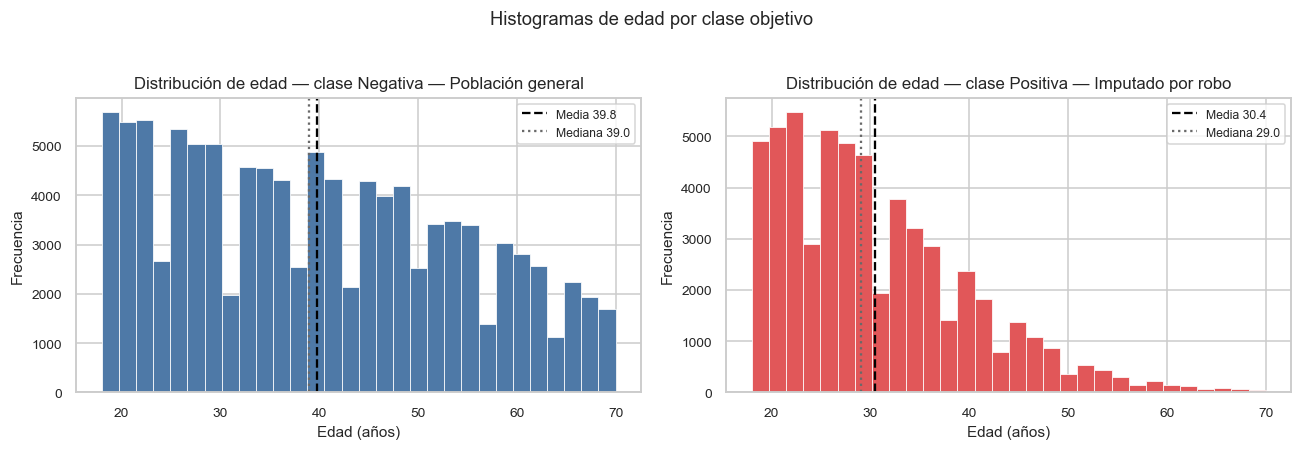

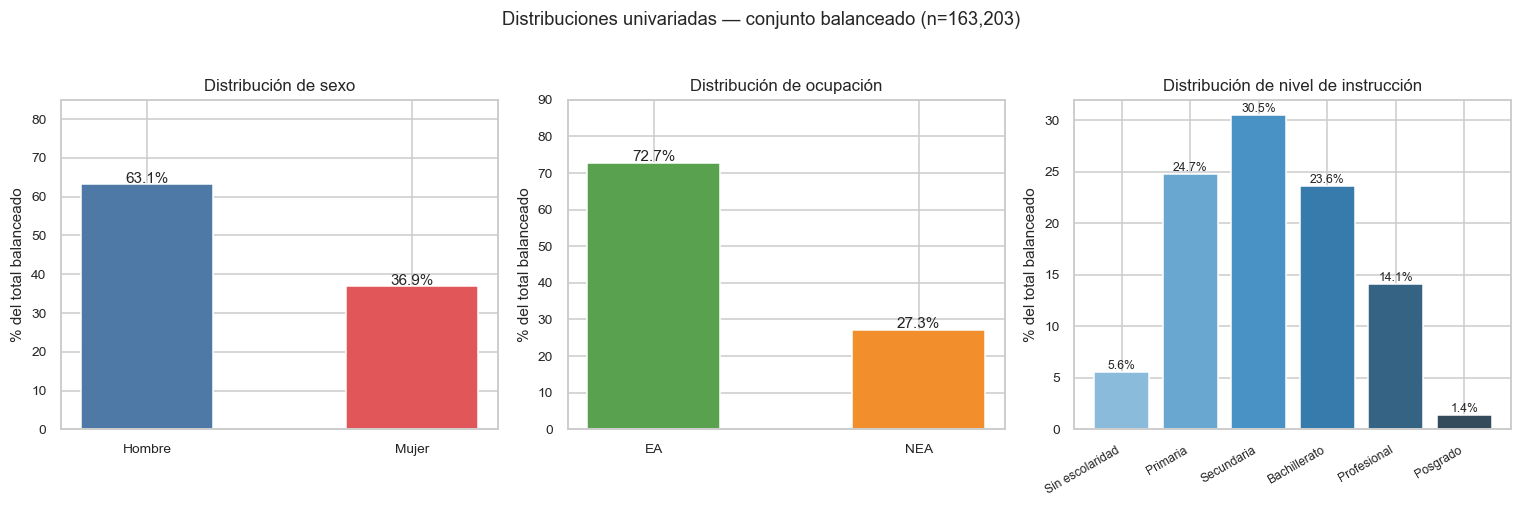

In [7]:
# ── Histograma de edad por clase ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (clase, grupo) in zip(axes, balanceado.groupby("clase")):
    ax.hist(grupo["edad"], bins=30, color=COLORES_CLASE[clase],
            edgecolor="white", linewidth=0.5)
    ax.axvline(grupo["edad"].mean(), color="black", linestyle="--",
               linewidth=1.5, label=f"Media {grupo['edad'].mean():.1f}")
    ax.axvline(grupo["edad"].median(), color="dimgray", linestyle=":",
               linewidth=1.5, label=f"Mediana {grupo['edad'].median():.1f}")
    etiq = "Positiva — Imputado por robo" if clase == "SI" else "Negativa — Población general"
    ax.set_title(f"Distribución de edad — clase {etiq}")
    ax.set_xlabel("Edad (años)")
    ax.set_ylabel("Frecuencia")
    ax.legend(fontsize=8)

plt.suptitle("Histogramas de edad por clase objetivo", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# ── Gráficos de barras para variables categóricas ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# Sexo
vals_sexo = balanceado["sexo"].value_counts(normalize=True).mul(100).reindex(["H", "M"])
bars = axes[0].bar(["Hombre", "Mujer"], vals_sexo.values,
                   color=["#4e79a7", "#e15759"], width=0.5, edgecolor="white")
for bar, v in zip(bars, vals_sexo.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f"{v:.1f}%", ha="center", fontsize=10)
axes[0].set_title("Distribución de sexo")
axes[0].set_ylabel("% del total balanceado")
axes[0].set_ylim(0, 85)

# Ocupación
vals_ocup = balanceado["ocupacion"].value_counts(normalize=True).mul(100)
bars = axes[1].bar(vals_ocup.index, vals_ocup.values,
                   color=["#59a14f", "#f28e2b"], width=0.5, edgecolor="white")
for bar, v in zip(bars, vals_ocup.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f"{v:.1f}%", ha="center", fontsize=10)
axes[1].set_title("Distribución de ocupación")
axes[1].set_ylabel("% del total balanceado")
axes[1].set_ylim(0, 90)

# Nivel de instrucción
etq_ni = [ETIQUETA_ESCOLARIDAD.get(i, str(i)) for i in range(1, 7)]
vals_ni = (balanceado["nivel_instruccion"].value_counts(normalize=True)
           .reindex(range(1, 7)).mul(100).fillna(0))
pal = sns.color_palette("Blues_d", 6)
bars = axes[2].bar(range(1, 7), vals_ni.values, color=pal, edgecolor="white")
for bar, v in zip(bars, vals_ni.values):
    if v > 0.5:
        axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                     f"{v:.1f}%", ha="center", fontsize=8)
axes[2].set_xticks(range(1, 7))
axes[2].set_xticklabels(etq_ni, rotation=30, ha="right", fontsize=8)
axes[2].set_title("Distribución de nivel de instrucción")
axes[2].set_ylabel("% del total balanceado")

plt.suptitle("Distribuciones univariadas — conjunto balanceado (n=163,203)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

**Hallazgos de las distribuciones univariadas.**

- **Edad.** Ambas distribuciones presentan asimetría positiva, acentuada en la clase positiva.
  El histograma de las personas imputadas muestra un pico pronunciado entre los 20 y los 28 años
  seguido de un descenso monótono, mientras que la clase negativa exhibe una distribución mucho
  más aplanada que se extiende de manera casi uniforme entre los 25 y los 55 años. La forma de
  ambas curvas es la manifestación gráfica de la diferencia de rangos intercuartílicos
  documentada en el apartado anterior.

- **Sexo.** En el conjunto balanceado los hombres representan el **63.1%** y las mujeres el
  36.9%. Esta proporción no es representativa de la población mexicana: es el resultado
  aritmético de combinar una fuente judicial predominantemente masculina con una encuesta de
  composición equilibrada, en la proporción 35/65 fijada por el balanceo.

- **Ocupación.** La condición económicamente activa concentra el **72.7%** del conjunto
  balanceado frente al 27.3% de la no activa.

- **Nivel de instrucción.** La categoría modal es **secundaria, con el 30.5%** del conjunto,
  seguida de primaria (24.7%) y bachillerato (23.6%). Los extremos de la escala tienen presencia
  marginal: sin escolaridad reúne el 5.6% y posgrado apenas el 1.4%. La concentración en los
  niveles intermedios es coherente con la estructura educativa de la población adulta mexicana
  de 18 a 70 años y no constituye una anomalía del conjunto.

### 15.3 Análisis bivariado — relación entre predictoras y clase objetivo

Se examinan las distribuciones de cada variable predictora condicionadas a la clase objetivo,
con el propósito de identificar el poder discriminatorio de cada característica. Se construyen
distribuciones superpuestas para la edad y gráficos de barras agrupadas para las variables
categóricas, expresados como porcentajes dentro de cada clase para facilitar la comparación.

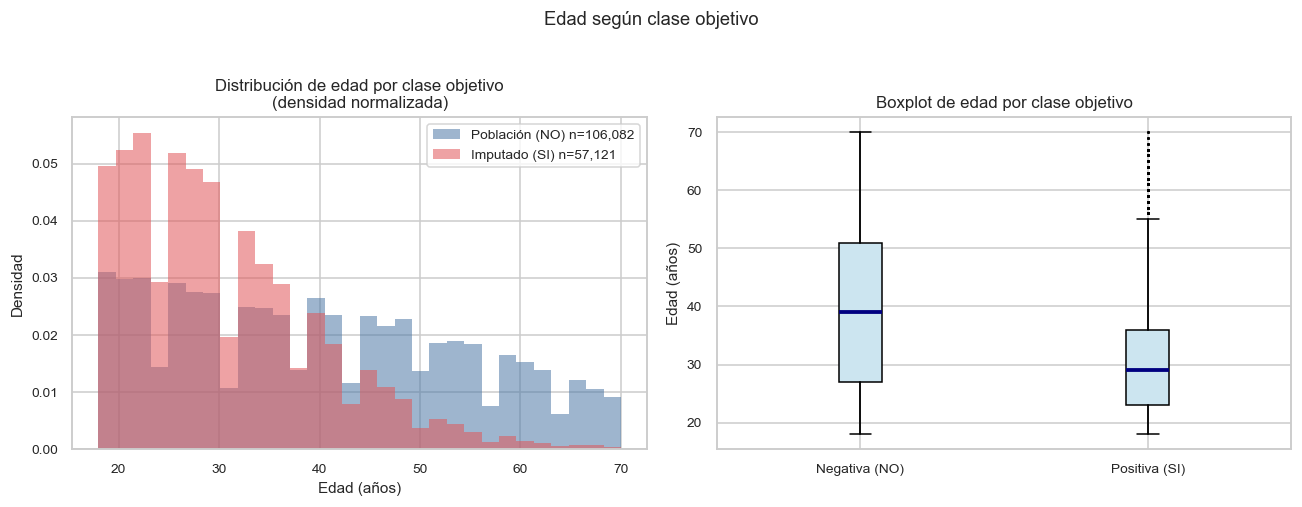

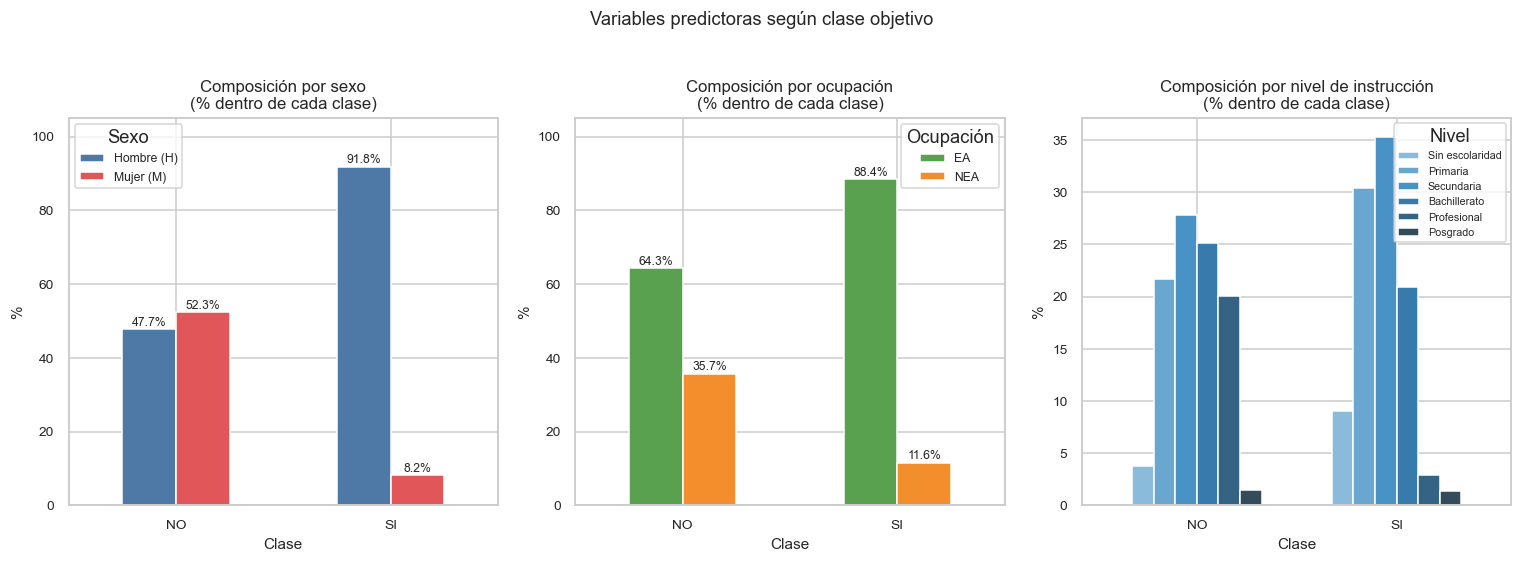

Diferencias en edad por clase:
       media  mediana   q25   q75
clase                            
NO     39.79     39.0  27.0  51.0
SI     30.45     29.0  23.0  36.0


In [8]:
# ── Distribuciones de edad superpuestas y boxplot comparativo ──────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Histograma superpuesto (densidad normalizada)
for clase, grupo in balanceado.groupby("clase"):
    etiq = f"{'Imputado (SI)' if clase == 'SI' else 'Población (NO)'} n={len(grupo):,}"
    axes[0].hist(grupo["edad"], bins=30, alpha=0.55,
                 color=COLORES_CLASE[clase], label=etiq,
                 density=True, edgecolor="none")
axes[0].set_xlabel("Edad (años)")
axes[0].set_ylabel("Densidad")
axes[0].set_title("Distribución de edad por clase objetivo\n(densidad normalizada)")
axes[0].legend(fontsize=9)

# Boxplot comparativo
datos_box = [balanceado[balanceado["clase"] == c]["edad"].values
             for c in ["NO", "SI"]]
bp = axes[1].boxplot(datos_box, patch_artist=True, notch=False,
                     boxprops=dict(facecolor="#cce5f0"),
                     medianprops=dict(color="navy", linewidth=2.5),
                     whiskerprops=dict(linewidth=1.2),
                     flierprops=dict(marker=".", markersize=1.5,
                                     color="steelblue", alpha=0.2))
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(["Negativa (NO)", "Positiva (SI)"])
axes[1].set_ylabel("Edad (años)")
axes[1].set_title("Boxplot de edad por clase objetivo")
plt.suptitle("Edad según clase objetivo", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# ── Variables categóricas por clase ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Sexo x clase
tbl_sx = pd.crosstab(balanceado["clase"], balanceado["sexo"],
                     normalize="index").mul(100)
tbl_sx.columns = ["Hombre (H)", "Mujer (M)"]
tbl_sx.plot(kind="bar", ax=axes[0], color=["#4e79a7", "#e15759"],
            edgecolor="white", width=0.5, rot=0)
axes[0].set_title("Composición por sexo\n(% dentro de cada clase)")
axes[0].set_xlabel("Clase")
axes[0].set_ylabel("%")
axes[0].set_ylim(0, 105)
axes[0].legend(title="Sexo", fontsize=8)
for bar in axes[0].patches:
    h = bar.get_height()
    if h > 2:
        axes[0].text(bar.get_x() + bar.get_width() / 2, h + 1,
                     f"{h:.1f}%", ha="center", fontsize=8)

# Ocupación x clase
tbl_oc = pd.crosstab(balanceado["clase"], balanceado["ocupacion"],
                     normalize="index").mul(100)
tbl_oc.plot(kind="bar", ax=axes[1], color=["#59a14f", "#f28e2b"],
            edgecolor="white", width=0.5, rot=0)
axes[1].set_title("Composición por ocupación\n(% dentro de cada clase)")
axes[1].set_xlabel("Clase")
axes[1].set_ylabel("%")
axes[1].set_ylim(0, 105)
axes[1].legend(title="Ocupación", fontsize=8)
for bar in axes[1].patches:
    h = bar.get_height()
    if h > 2:
        axes[1].text(bar.get_x() + bar.get_width() / 2, h + 1,
                     f"{h:.1f}%", ha="center", fontsize=8)

# Nivel instrucción x clase
tbl_ni = pd.crosstab(balanceado["clase"], balanceado["nivel_instruccion"],
                     normalize="index").mul(100)
tbl_ni.columns = [ETIQUETA_ESCOLARIDAD.get(c, c) for c in tbl_ni.columns]
tbl_ni.plot(kind="bar", ax=axes[2],
            color=sns.color_palette("Blues_d", 6),
            edgecolor="white", width=0.65, rot=0)
axes[2].set_title("Composición por nivel de instrucción\n(% dentro de cada clase)")
axes[2].set_xlabel("Clase")
axes[2].set_ylabel("%")
axes[2].legend(title="Nivel", fontsize=7, loc="upper right")

plt.suptitle("Variables predictoras según clase objetivo", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# ── Tabla numérica para el informe ────────────────────────────────────────
print("Diferencias en edad por clase:")
print(balanceado.groupby("clase")["edad"]
      .agg(media="mean", mediana="median",
           q25=lambda x: x.quantile(0.25),
           q75=lambda x: x.quantile(0.75))
      .round(2).to_string())

**Hallazgos del análisis bivariado.**

- **Edad y clase.** El histograma superpuesto muestra que las densidades de ambas clases se
  cruzan en torno a los 33 años: por debajo de ese umbral predomina la clase positiva y por
  encima la negativa. El boxplot hace visible que **el tercer cuartil de la clase positiva (36
  años) se sitúa por debajo de la mediana de la negativa (39 años)**, lo que constituye una
  separación considerable para una única variable continua. No obstante, la superposición de
  los rangos entre los 23 y los 36 años implica que la edad por sí sola no discrimina
  perfectamente entre clases.

- **Sexo y clase.** El contraste es el más pronunciado de las cuatro predictoras: **91.8% de
  hombres en la clase positiva frente al 47.7% en la negativa**, una diferencia de 44 puntos
  porcentuales. Este resultado anticipa lo que confirmará el análisis de importancia de
  variables del apartado 16.4.

- **Nivel de instrucción y clase.** La distribución de la clase positiva está desplazada hacia
  los niveles inferiores: primaria y secundaria concentran el **65.7%** de las personas
  imputadas frente al 49.6% de la clase negativa. El desplazamiento se aprecia con mayor nitidez
  en el extremo superior de la escala, donde el nivel profesional pasa del 20.1% al 2.9%.

- **Ocupación y clase.** La diferencia entre clases es de 24 puntos porcentuales (88.4% frente a
  64.3% de población económicamente activa), inferior a la del sexo y a la del nivel de
  instrucción. Debe recordarse que esta variable presenta la comparabilidad más débil entre
  fuentes, tal como se documentó en los apartados 5 y 14, por lo que su lectura sustantiva ha de
  ser cautelosa.

### 15.4 Detección de anomalías y valores atípicos

Se aplica el método del rango intercuartílico (IQR) sobre la variable cuantitativa
continua (edad) para identificar observaciones con valores extremos, y se examina la
frecuencia marginal de las categorías cualitativas para detectar categorías que pudieran
introducir ruido en el modelado.

DETECCIÓN DE VALORES ATÍPICOS — método IQR (factor 1.5)


,Q1,Q3,IQR,Límite inferior,Límite superior,Atípicos (n),Atípicos (%)
Clase,,,,,,,
NO,27.0,51.0,24.0,-9.0,87.0,0,0.000
SI,23.0,36.0,13.0,3.5,55.5,1019,1.784


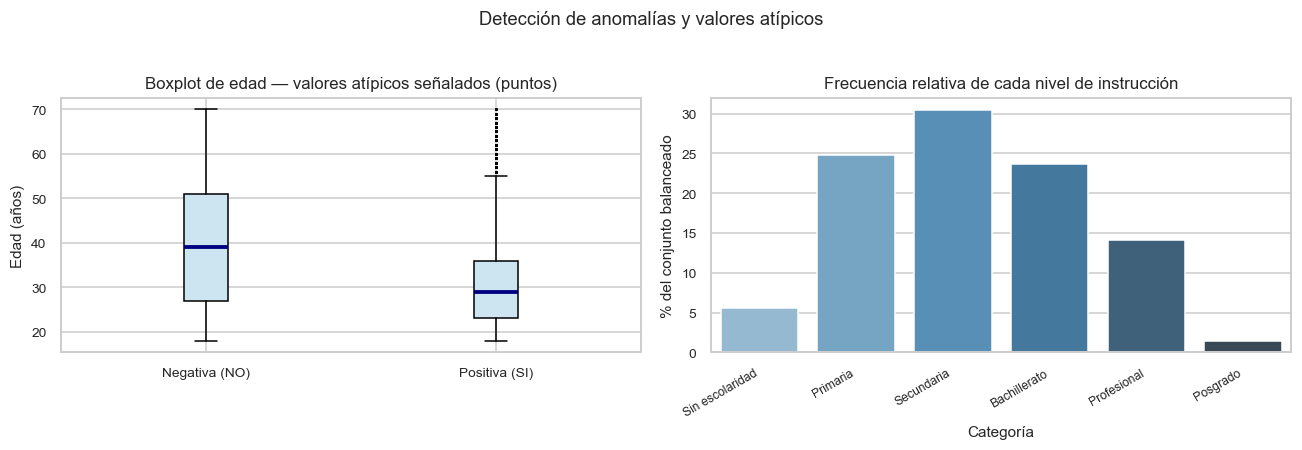

In [9]:
# ── Método IQR: límites y conteo de valores atípicos ──────────────────────
print("=" * 65)
print("DETECCIÓN DE VALORES ATÍPICOS — método IQR (factor 1.5)")
resumen_iqr = []
for clase, grupo in balanceado.groupby("clase"):
    Q1 = grupo["edad"].quantile(0.25)
    Q3 = grupo["edad"].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    atip = grupo[(grupo["edad"] < lim_inf) | (grupo["edad"] > lim_sup)]
    resumen_iqr.append({
        "Clase": clase, "Q1": Q1, "Q3": Q3, "IQR": IQR,
        "Límite inferior": round(lim_inf, 1),
        "Límite superior": round(lim_sup, 1),
        "Atípicos (n)": len(atip),
        "Atípicos (%)": round(len(atip) / len(grupo) * 100, 3),
    })
display(pd.DataFrame(resumen_iqr).set_index("Clase"))

# ── Boxplot con fliers ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

datos_box = [balanceado[balanceado["clase"] == c]["edad"].values
             for c in ["NO", "SI"]]
axes[0].boxplot(datos_box, patch_artist=True, notch=False,
                boxprops=dict(facecolor="#cce5f0"),
                medianprops=dict(color="navy", linewidth=2.5),
                flierprops=dict(marker=".", markersize=1.5,
                                color="coral", alpha=0.3))
axes[0].set_xticks([1, 2])
axes[0].set_xticklabels(["Negativa (NO)", "Positiva (SI)"])
axes[0].set_ylabel("Edad (años)")
axes[0].set_title("Boxplot de edad — valores atípicos señalados (puntos)")
# Frecuencia de categorías en variables cualitativas
categorias = []
for var in ["nivel_instruccion"]:
    vc = balanceado[var].value_counts().sort_index()
    pct = (vc / len(balanceado) * 100).round(2)
    for k, v in vc.items():
        categorias.append({
            "Variable": var,
            "Categoría": ETIQUETA_ESCOLARIDAD.get(k, str(k)),
            "Frecuencia": v,
            "% del total": round(v / len(balanceado) * 100, 2)
        })
df_cat = pd.DataFrame(categorias)
sns.barplot(data=df_cat, x="Categoría", y="% del total",
            ax=axes[1], palette="Blues_d", order=list(ETIQUETA_ESCOLARIDAD.values()))
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha="right", fontsize=8)
axes[1].set_title("Frecuencia relativa de cada nivel de instrucción")
axes[1].set_ylabel("% del conjunto balanceado")

plt.suptitle("Detección de anomalías y valores atípicos", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

**Hallazgos de la detección de anomalías.**

- **Ausencia total de atípicos en la clase negativa.** El método IQR arroja límites de −9.0 y
  87.0 años para esta clase, ambos situados fuera del rango admisible de 18 a 70 años fijado en
  el apartado 8. En consecuencia **ninguna observación puede clasificarse como atípica**: la
  amplitud del rango intercuartílico (24 años) hace que los umbrales excedan el propio dominio
  de la variable. Este resultado no indica ausencia de dispersión, sino que la distribución es
  lo bastante extendida como para que el criterio de Tukey resulte inoperante.

- **Atípicos concentrados en la clase positiva.** Con un rango intercuartílico de apenas 13
  años, los límites se estrechan a 3.5 y 55.5 años, y se identifican **1,019 observaciones
  atípicas, equivalentes al 1.78%** de la clase. La totalidad corresponde al extremo superior:
  personas mayores de 55 años imputadas por robo. Se trata de casos poco frecuentes pero
  perfectamente verosímiles, no de errores de registro.

- **Decisión sobre el tratamiento.** No se elimina ninguna de estas observaciones. Su condición
  de atípicas es un artefacto del criterio estadístico —consecuencia directa de la
  concentración etaria de la clase positiva— y no un indicio de error. Excluirlas supondría
  eliminar precisamente el segmento de mayor edad de las personas imputadas, sesgando aún más
  una distribución ya concentrada y empobreciendo la capacidad del modelo para reconocer
  perfiles menos frecuentes.

- **Categorías de baja frecuencia.** Posgrado (1.4% del conjunto) y sin escolaridad (5.6%)
  presentan las frecuencias más bajas. Su escasez puede incrementar la varianza de las
  estimaciones en esos niveles, pero los algoritmos de ensemble seleccionados manejan este
  desequilibrio sin necesidad de agrupar categorías.

- **Conclusión.** El conjunto no presenta anomalías estructurales. La validación de dominios
  ejecutada en el apartado 8 —que no eliminó ningún registro por sexo, ocupación o nivel de
  instrucción fuera de rango— confirma la ausencia de errores de codificación.

### 15.5 Verificación de supuestos

Se examina el cumplimiento de los supuestos estadísticos relevantes para los algoritmos
que se aplicarán en la fase de modelado:

1. **Normalidad de la variable cuantitativa.** Se aplica el test de Kolmogorov-Smirnov,
   apropiado para muestras grandes, ya que el test de Shapiro-Wilk está limitado a
   *n* < 5,000.
2. **Asociación entre predictoras categóricas y clase (Chi-cuadrado de Pearson).** Se
   complementa con la V de Cramér para cuantificar la magnitud de la asociación.
3. **Correlación entre predictoras** mediante el coeficiente de Spearman, para descartar
   multicolinealidad.

TEST DE KOLMOGOROV-SMIRNOV — normalidad de la edad
H₀: la distribución sigue una distribución Normal(μ, σ)
  Clase NO: estadístico=0.0816, p-valor=2.0667e-29 → Rechaza H₀ (no normal)
  Clase SI: estadístico=0.0985, p-valor=1.1468e-42 → Rechaza H₀ (no normal)

CHI-CUADRADO DE PEARSON — asociación de categóricas con la clase
H₀: la variable es independiente de la clase objetivo


,χ²,p-valor,V de Cramér,Decisión
Variable,,,,
sexo,31016.8,0.0,0.4359,Asociación significativa
ocupacion,10850.2,0.0,0.2578,Asociación significativa
nivel_instruccion,11707.0,0.0,0.2678,Asociación significativa



CORRELACIÓN DE SPEARMAN — entre predictoras cuantitativas y ordinales
  edad                      ↔ nivel_instruccion        : ρ=-0.1447  p=0.00e+00
  edad                      ↔ clase (binaria)          : ρ=-0.3113  p=0.00e+00
  nivel_instruccion         ↔ clase (binaria)          : ρ=-0.2340  p=0.00e+00


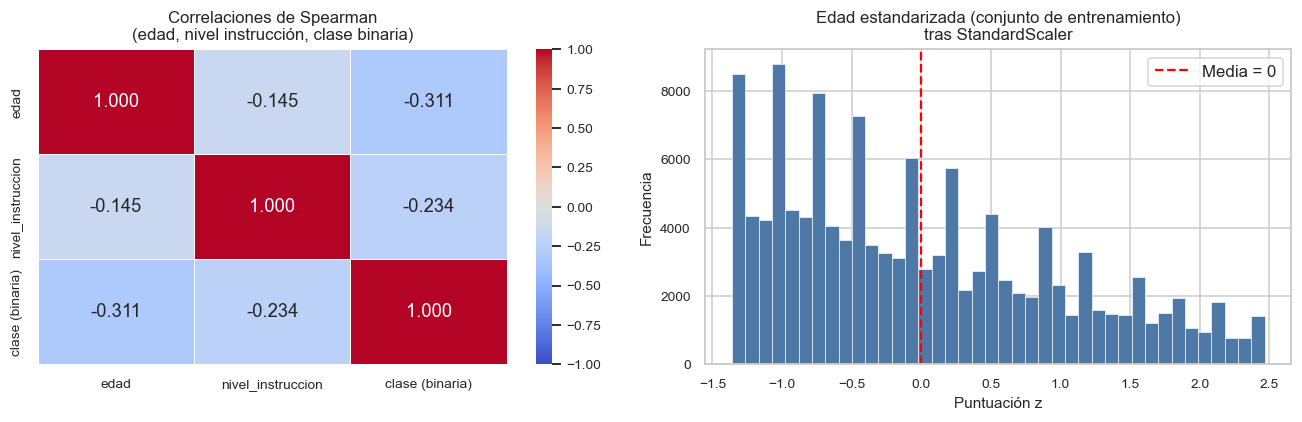

In [10]:
from scipy.stats import kstest, chi2_contingency, spearmanr, norm as norm_dist

# ── 1. Normalidad de la edad ──────────────────────────────────────────────
print("=" * 65)
print("TEST DE KOLMOGOROV-SMIRNOV — normalidad de la edad")
print("H₀: la distribución sigue una distribución Normal(μ, σ)")
for clase, grupo in balanceado.groupby("clase"):
    muestra = grupo["edad"].sample(n=min(5000, len(grupo)), random_state=SEMILLA)
    # Se pasa la CDF como función lambda para evitar incompatibilidades de scipy
    cdf_normal = norm_dist(loc=muestra.mean(), scale=muestra.std()).cdf
    ks_stat, p_val = kstest(muestra, cdf_normal)
    decision = "Rechaza H₀ (no normal)" if p_val < 0.05 else "No rechaza H₀"
    print(f"  Clase {clase}: estadístico={ks_stat:.4f}, p-valor={p_val:.4e} → {decision}")

# ── 2. Chi-cuadrado + V de Cramér ────────────────────────────────────────
print("\n" + "=" * 65)
print("CHI-CUADRADO DE PEARSON — asociación de categóricas con la clase")
print("H₀: la variable es independiente de la clase objetivo")
res_chi2 = []
for var in ["sexo", "ocupacion", "nivel_instruccion"]:
    tabla = pd.crosstab(balanceado[var], balanceado["clase"])
    chi2, p, dof, _ = chi2_contingency(tabla)
    n = tabla.values.sum()
    v = np.sqrt(chi2 / (n * (min(tabla.shape) - 1)))
    decision = "Asociación significativa" if p < 0.05 else "Sin evidencia"
    res_chi2.append({"Variable": var, "χ²": round(chi2, 1), "p-valor": p,
                     "V de Cramér": round(v, 4), "Decisión": decision})
display(pd.DataFrame(res_chi2).set_index("Variable"))

# ── 3. Correlación de Spearman ────────────────────────────────────────────
print("\n" + "=" * 65)
print("CORRELACIÓN DE SPEARMAN — entre predictoras cuantitativas y ordinales")
y_bin = (balanceado["clase"] == "SI").astype(int)
pares = [("edad", "nivel_instruccion"),
         ("edad", "clase (binaria)"),
         ("nivel_instruccion", "clase (binaria)")]
datos_extra = balanceado[["edad", "nivel_instruccion"]].assign(**{"clase (binaria)": y_bin})
for a, b in pares:
    rho, p_rho = spearmanr(datos_extra[a], datos_extra[b])
    print(f"  {a:25s} ↔ {b:25s}: ρ={rho:+.4f}  p={p_rho:.2e}")

# ── Mapa de calor de correlación ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
corr_mat = datos_extra.corr(method="spearman")
sns.heatmap(corr_mat, annot=True, fmt=".3f", cmap="coolwarm",
            center=0, ax=axes[0], linewidths=0.5, vmin=-1, vmax=1)
axes[0].set_title("Correlaciones de Spearman\n(edad, nivel instrucción, clase binaria)")

# Histograma de la edad estandarizada (partición de entrenamiento)
axes[1].hist(X_entrena["edad"], bins=40, color="#4e79a7",
             edgecolor="white", linewidth=0.4)
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5, label="Media = 0")
axes[1].set_title("Edad estandarizada (conjunto de entrenamiento)\ntras StandardScaler")
axes[1].set_xlabel("Puntuación z")
axes[1].set_ylabel("Frecuencia")
axes[1].legend()
plt.tight_layout()
plt.show()

**Hallazgos de la verificación de supuestos.**

- **Normalidad rechazada en ambas clases.** El test de Kolmogorov-Smirnov arroja un estadístico
  D de 0.0832 para la clase negativa (p = 1.5 × 10⁻³⁰) y de 0.0983 para la positiva
  (p = 1.6 × 10⁻⁴²). Ambos p-valores conducen al rechazo de la hipótesis nula con holgura. El
  resultado era previsible: la asimetría positiva y el truncamiento en 18 años impiden que la
  edad siga una distribución normal. **Esta violación no invalida el modelado propuesto.** Los
  cuatro algoritmos basados en particiones y probabilidades condicionales —árbol de decisión,
  Random Forest, XGBoost y Naive Bayes gaussiano— no requieren normalidad de los predictores;
  para la red neuronal multicapa, la estandarización aplicada en el apartado 12 basta para
  garantizar la convergencia del optimizador.

- **Asociación significativa en las tres variables categóricas, con jerarquía clara.** Los tres
  contrastes de chi-cuadrado rechazan la independencia con p-valores indistinguibles de cero.
  La V de Cramér revela, sin embargo, magnitudes muy dispares:

  | Variable | χ² | V de Cramér | Interpretación |
  |---|---|---|---|
  | Sexo | 31,016.8 | **0.4359** | Asociación moderada-fuerte |
  | Nivel de instrucción | 11,707.0 | 0.2678 | Asociación moderada |
  | Ocupación | 10,850.2 | 0.2578 | Asociación moderada |

  El sexo presenta una asociación con la clase **1.6 veces más intensa** que las otras dos
  variables, que resultan prácticamente equivalentes entre sí. Este hallazgo anticipa la
  jerarquía de importancia que confirmarán los modelos en el apartado 16.4.

- **Ausencia de multicolinealidad.** La correlación de Spearman entre edad y nivel de
  instrucción es de ρ = −0.1447, magnitud débil que descarta cualquier problema de
  colinealidad entre las predictoras cuantitativas. El signo negativo es coherente con la
  expansión de la cobertura educativa en México durante las últimas décadas: las cohortes más
  jóvenes alcanzan niveles de escolaridad superiores.

- **Correlación de las predictoras con la clase.** Ambas asociaciones son negativas y
  estadísticamente significativas: edad (ρ = −0.3113) y nivel de instrucción (ρ = −0.2340).
  A mayor edad y a mayor escolaridad, menor probabilidad de pertenecer a la clase positiva.
  El sentido de ambas relaciones es consistente con la literatura criminológica sobre delitos
  patrimoniales y con los estadísticos descriptivos del apartado 15.1.

### 15.6 Contexto territorial — Carpetas de investigación FGJ-CDMX

La tabla de contexto construida en la sección 6 contiene el número de carpetas de
investigación por robo registradas en cada alcaldía de la Ciudad de México entre 2018 y
2021. Se visualizan la tendencia temporal agregada y la distribución por alcaldía. Esta
información no forma parte de la matriz de modelado —por las razones documentadas en los
apartados 10 y 14— sino que sirve de insumo al análisis descriptivo territorial y al
tablero ejecutivo del proyecto.

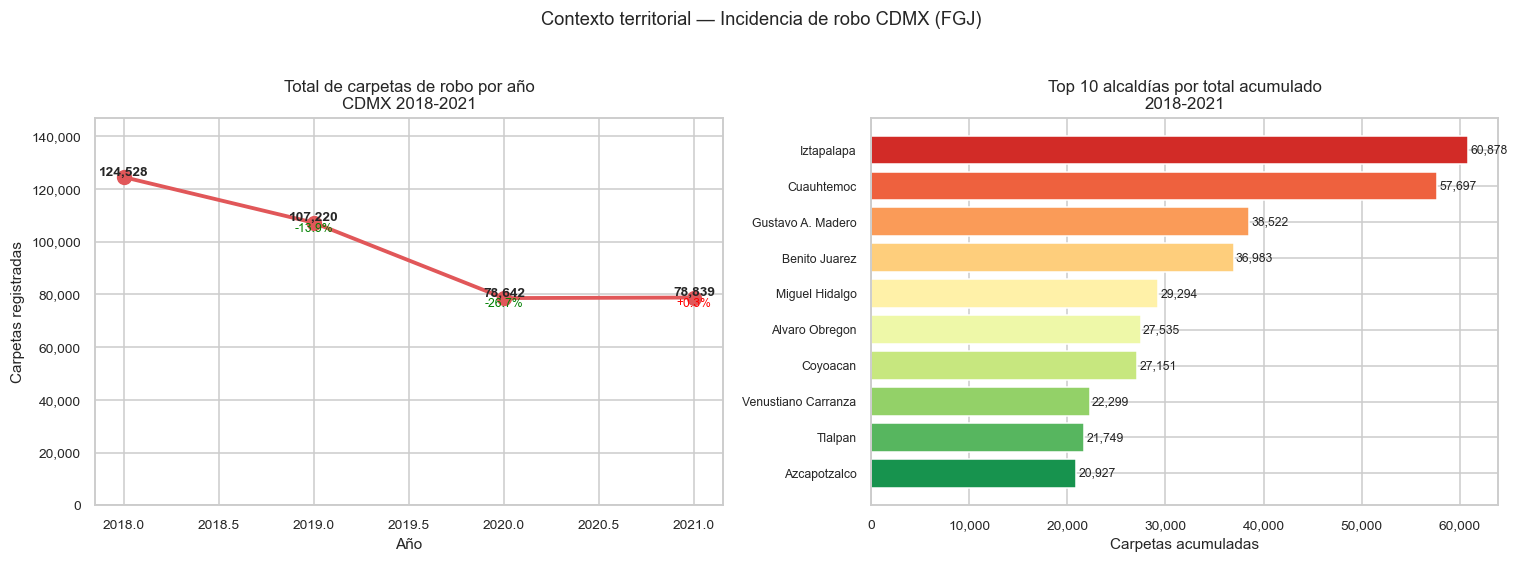

anio,2018,2019,2020,2021,Total,Var% 18→21
alcaldia,,,,,,
IZTAPALAPA,19373,17213,12453,11839,60878,-38.9
CUAUHTEMOC,20363,15733,10469,11132,57697,-45.3
GUSTAVO A. MADERO,12413,10494,7806,7809,38522,-37.1
BENITO JUAREZ,12578,10353,7236,6816,36983,-45.8
COYOACAN,8156,6962,5826,6207,27151,-23.9
MIGUEL HIDALGO,9516,8518,5632,5628,29294,-40.9
ALVARO OBREGON,8061,7957,6047,5470,27535,-32.1
TLALPAN,5991,6066,4856,4836,21749,-19.3
AZCAPOTZALCO,6765,5063,4459,4640,20927,-31.4


In [11]:
# ── Tendencia temporal ────────────────────────────────────────────────────
total_anio = contexto.groupby("anio")["robos_registrados"].sum()
variacion = total_anio.pct_change().mul(100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(total_anio.index, total_anio.values,
             marker="o", color="#e15759", linewidth=2.5, markersize=9)
for x, y in zip(total_anio.index, total_anio.values):
    axes[0].text(x, y + 600, f"{y:,}", ha="center", fontsize=9, fontweight="bold")
axes[0].set_title("Total de carpetas de robo por año\nCDMX 2018-2021")
axes[0].set_xlabel("Año")
axes[0].set_ylabel("Carpetas registradas")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[0].set_ylim(0, total_anio.max() * 1.18)
for anio in total_anio.index[1:]:
    var = variacion[anio]
    color = "green" if var < 0 else "red"
    axes[0].annotate(f"{var:+.1f}%", xy=(anio, total_anio[anio]),
                     xytext=(anio, total_anio[anio] - 3500),
                     ha="center", fontsize=8, color=color)

# ── Top alcaldías (barras horizontales) ──────────────────────────────────
top_alc = (contexto.groupby("alcaldia")["robos_registrados"].sum()
           .sort_values(ascending=True).tail(10))
colores = sns.color_palette("RdYlGn_r", 10)
bars = axes[1].barh(range(len(top_alc)), top_alc.values,
                    color=colores, edgecolor="white")
axes[1].set_yticks(range(len(top_alc)))
axes[1].set_yticklabels([a.title() for a in top_alc.index], fontsize=8)
for bar, v in zip(bars, top_alc.values):
    axes[1].text(v + 200, bar.get_y() + bar.get_height() / 2,
                 f"{v:,}", va="center", fontsize=8)
axes[1].set_title("Top 10 alcaldías por total acumulado\n2018-2021")
axes[1].set_xlabel("Carpetas acumuladas")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.suptitle("Contexto territorial — Incidencia de robo CDMX (FGJ)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# ── Tabla pivote con variación ────────────────────────────────────────────
pivot = (contexto.pivot(index="alcaldia", columns="anio", values="robos_registrados")
         .sort_values(2021, ascending=False).fillna(0).astype(int))
pivot["Total"] = pivot.sum(axis=1)
pivot["Var% 18→21"] = ((pivot[2021] / pivot[2018] - 1) * 100).round(1)
display(pivot)

**Hallazgos del contexto territorial.**

- **Reducción acumulada del 36.7% en el periodo.** Las carpetas de investigación por robo
  descendieron de **124,528 en 2018 a 78,839 en 2021**. La trayectoria no es uniforme: la caída
  fue del 13.9% entre 2018 y 2019, se aceleró hasta el **26.7% entre 2019 y 2020** —el año de
  las restricciones de movilidad por la pandemia de COVID-19— y se detuvo por completo en 2021,
  con una variación de apenas +0.25% respecto del año previo. El patrón sugiere que la
  contracción de 2020 respondió en buena medida a factores de exposición y oportunidad
  —menor circulación de personas y bienes en el espacio público— más que a una transformación
  estructural de la incidencia.

- **Concentración territorial estable.** Iztapalapa (60,878 carpetas acumuladas) y Cuauhtémoc
  (57,697) encabezan el registro durante todo el periodo y reúnen entre ambas el **30.4% del
  total** de la ciudad. Les siguen Gustavo A. Madero (38,522) y Benito Juárez (36,983). La
  jerarquía entre alcaldías se mantiene prácticamente inalterada entre 2018 y 2021, lo que
  indica que la reducción operó de manera proporcional y no reconfiguró el mapa del delito.

- **La caída fue más pronunciada en las alcaldías centrales.** Benito Juárez (−45.8%),
  Cuauhtémoc (−45.3%) e Iztacalco (−44.7%) registraron los descensos más acusados, mientras que
  La Magdalena Contreras (−6.7%), Milpa Alta (−7.2%) y Cuajimalpa (−11.2%) apenas se movieron.
  Las demarcaciones con mayor concentración de actividad comercial, oficinas y flujo de
  población flotante fueron las más sensibles a la reducción de la movilidad; las de carácter
  predominantemente residencial o periférico resultaron mucho menos afectadas.

- **Implicaciones para el proyecto.** Esta tabla enriquece la dimensión territorial del análisis
  sin comprometer la integridad del modelo predictivo, del que permanece excluida por las
  razones expuestas en los apartados 10 y 14. El tablero ejecutivo podrá superponer la
  predicción individual del modelo con esta capa de incidencia agregada, ofreciendo una lectura
  conjunta del perfil sociodemográfico y del contexto espacial.

## 16. Modelado Predictivo

La fase de modelado implementa los cinco algoritmos de clasificación supervisada definidos
en el apartado 3.2.3 de la Entrega 1: Árbol de Decisión (C4.5/J48), Naive Bayes gaussiano,
Random Forest, XGBoost y Red Neuronal Multicapa (MLP). El proceso sigue las etapas
establecidas en el apartado 3.3:

1. Validación cruzada estratificada de 10 pliegues sobre la partición de entrenamiento.
2. Entrenamiento final sobre la totalidad de la partición de entrenamiento.
3. Evaluación sobre la partición de prueba mediante las métricas seleccionadas.
4. Análisis de importancia de variables.
5. Matrices de confusión y selección del modelo.

La **variable objetivo** es `clase` (1 = SI = persona imputada por robo; 0 = NO).
Las **predictoras** son las cuatro columnas de la matriz principal: `edad` (normalizada
con puntuación z), `nivel_instruccion` (ordinal 1-6), `sexo_M` (0/1) y `ocupacion_NEA`
(0/1), construidas en el apartado 12.

In [12]:
%pip install xgboost --quiet

Note: you may need to restart the kernel to use updated packages.


In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay, RocCurveDisplay)
from xgboost import XGBClassifier

SEMILLA_MODEL = SEMILLA

# ── Definición de los cinco clasificadores ───────────────────────────────
modelos = {
    "Árbol Decisión": DecisionTreeClassifier(
        max_depth=8, min_samples_leaf=50,
        criterion="entropy", random_state=SEMILLA_MODEL),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=12, min_samples_leaf=30,
        n_jobs=-1, random_state=SEMILLA_MODEL),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=SEMILLA_MODEL, verbosity=0),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(64, 32), activation="relu",
        solver="adam", alpha=0.001, max_iter=300,
        early_stopping=True, random_state=SEMILLA_MODEL),
}

print("Modelos inicializados:")
for nombre in modelos:
    print(f"  {nombre}")
print(f"\nMatriz de entrenamiento: {X_entrena.shape[0]:,} registros × {X_entrena.shape[1]} predictoras")
print(f"Predictoras: {list(X_entrena.columns)}")

Modelos inicializados:
  Árbol Decisión
  Naive Bayes
  Random Forest
  XGBoost
  MLP

Matriz de entrenamiento: 130,562 registros × 4 predictoras
Predictoras: ['edad', 'nivel_instruccion', 'sexo_M', 'ocupacion_NEA']


### 16.1 Validación cruzada estratificada (10 pliegues)

Se evalúa cada modelo mediante validación cruzada estratificada de 10 pliegues sobre el
conjunto de entrenamiento. La estratificación garantiza que cada pliegue mantenga la
proporción 65/35 entre clases. Se reportan la media y la desviación estándar de tres
métricas a través de los diez pliegues: exactitud (accuracy), F1-score de la clase positiva
y AUC-ROC.

In [14]:
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEMILLA_MODEL)

print("Ejecutando validación cruzada de 10 pliegues...")
resultados_cv = []
for nombre, modelo in modelos.items():
    print(f"  Evaluando {nombre}...", end=" ", flush=True)
    cv = cross_validate(
        modelo, X_entrena, y_entrena, cv=kf,
        scoring=["accuracy", "f1", "roc_auc"],
        return_train_score=False, n_jobs=1
    )
    resultados_cv.append({
        "Modelo":           nombre,
        "Accuracy ± std":   f"{cv['test_accuracy'].mean():.4f} ± {cv['test_accuracy'].std():.4f}",
        "F1 ± std":         f"{cv['test_f1'].mean():.4f} ± {cv['test_f1'].std():.4f}",
        "AUC-ROC ± std":    f"{cv['test_roc_auc'].mean():.4f} ± {cv['test_roc_auc'].std():.4f}",
        "_auc_mean":        cv["test_roc_auc"].mean(),
    })
    print(f"AUC={cv['test_roc_auc'].mean():.4f} ± {cv['test_roc_auc'].std():.4f}")

cv_df = (pd.DataFrame(resultados_cv)
         .sort_values("_auc_mean", ascending=False)
         .drop(columns="_auc_mean")
         .set_index("Modelo"))
print("\nResultados de la validación cruzada (media ± desviación estándar):")
display(cv_df)

Ejecutando validación cruzada de 10 pliegues...
  Evaluando Árbol Decisión... AUC=0.8702 ± 0.0022
  Evaluando Naive Bayes... AUC=0.8444 ± 0.0025
  Evaluando Random Forest... AUC=0.8713 ± 0.0023
  Evaluando XGBoost... AUC=0.8717 ± 0.0024
  Evaluando MLP... AUC=0.8698 ± 0.0024

Resultados de la validación cruzada (media ± desviación estándar):


,Accuracy ± std,F1 ± std,AUC-ROC ± std
Modelo,,,
XGBoost,0.8005 ± 0.0024,0.7215 ± 0.0046,0.8717 ± 0.0024
Random Forest,0.7994 ± 0.0022,0.7191 ± 0.0041,0.8713 ± 0.0023
Árbol Decisión,0.7999 ± 0.0022,0.7233 ± 0.0040,0.8702 ± 0.0022
MLP,0.7992 ± 0.0019,0.7203 ± 0.0043,0.8698 ± 0.0024
Naive Bayes,0.7433 ± 0.0027,0.6795 ± 0.0036,0.8444 ± 0.0025


**Interpretación de la validación cruzada.**

- **Cuatro de los cinco modelos son estadísticamente indistinguibles.** XGBoost (AUC = 0.8717),
  Random Forest (0.8713), Árbol de Decisión (0.8702) y MLP (0.8698) se separan por un margen
  máximo de **0.0019 puntos de AUC, inferior a la desviación estándar entre pliegues de cada
  modelo (± 0.0022 a ± 0.0024)**. La diferencia entre ellos carece por tanto de significación
  práctica: con cuatro predictoras de baja cardinalidad, la frontera de decisión óptima es
  suficientemente simple como para que la capacidad adicional de los modelos de ensemble no
  encuentre estructura que explotar.

- **Naive Bayes queda claramente por detrás.** Su AUC de 0.8444 se sitúa 0.027 puntos por
  debajo del líder, distancia que sí excede con amplitud la variabilidad entre pliegues. La
  brecha se explica por el supuesto de independencia condicional entre predictoras, que el
  conjunto no satisface —la correlación documentada entre edad y nivel de instrucción lo
  contradice— y por el ajuste de una gaussiana a la variable de edad, cuya no normalidad quedó
  establecida en el apartado 15.5. Su exactitud (0.7433) es asimismo la más baja del grupo.

- **Estabilidad elevada en todos los casos.** Las desviaciones estándar del AUC oscilan entre
  0.0022 y 0.0025 a lo largo de los diez pliegues, lo que representa menos del 0.3% del valor de
  la métrica. Ningún modelo muestra dependencia de la partición concreta de los datos, señal de
  que el volumen de entrenamiento —130,562 registros— es holgadamente suficiente para la
  complejidad de los modelos ajustados.

- **Nivel de desempeño alcanzado.** Un AUC en torno a 0.87 con únicamente cuatro variables
  sociodemográficas supera lo que cabría anticipar para este tipo de problema. El apartado 16.4
  identifica el origen de este resultado y el 16.6 discute las cautelas que impone su
  interpretación.

### 16.2 Entrenamiento final y evaluación en la partición de prueba

Se entrena cada modelo sobre la totalidad del conjunto de entrenamiento y se evalúa
sobre la partición de prueba —que no participó en ninguna etapa previa— mediante las
cinco métricas definidas: exactitud, precisión, cobertura, F1 y AUC-ROC.

In [16]:
print("Entrenando y evaluando en la partición de prueba...")
metricas_prueba = []
modelos_entrenados = {}

for nombre, modelo in modelos.items():
    print(f"  {nombre}...", end=" ", flush=True)
    modelo.fit(X_entrena, y_entrena)
    modelos_entrenados[nombre] = modelo

    y_pred = modelo.predict(X_prueba)
    y_prob = modelo.predict_proba(X_prueba)[:, 1]
    auc = roc_auc_score(y_prueba, y_prob)
    f1  = f1_score(y_prueba, y_pred, zero_division=0)
    metricas_prueba.append({
        "Modelo":    nombre,
        "Accuracy":  round(accuracy_score(y_prueba, y_pred), 4),
        "Precisión": round(precision_score(y_prueba, y_pred, zero_division=0), 4),
        "Cobertura": round(recall_score(y_prueba, y_pred, zero_division=0), 4),
        "F1":        round(f1, 4),
        "AUC-ROC":   round(auc, 4),
    })
    print(f"AUC={auc:.4f}  F1={f1:.4f}")

met_df = (pd.DataFrame(metricas_prueba)
          .sort_values("AUC-ROC", ascending=False)
          .set_index("Modelo"))
print("\nMétricas en la partición de prueba (n=32,641):")
display(met_df)

mejor = met_df["AUC-ROC"].idxmax()
print(f"\nMejor modelo por AUC-ROC: {mejor} ({met_df.loc[mejor, 'AUC-ROC']:.4f})")

Entrenando y evaluando en la partición de prueba...
  Árbol Decisión... AUC=0.8687  F1=0.7255
  Naive Bayes... AUC=0.8423  F1=0.6770
  Random Forest... AUC=0.8694  F1=0.7154
  XGBoost... AUC=0.8702  F1=0.7210
  MLP... AUC=0.8686  F1=0.7127

Métricas en la partición de prueba (n=32,641):


,Accuracy,Precisión,Cobertura,F1,AUC-ROC
Modelo,,,,,
XGBoost,0.8000,0.7043,0.7385,0.7210,0.8702
Random Forest,0.7984,0.7069,0.7242,0.7154,0.8694
Árbol Decisión,0.8006,0.7000,0.7530,0.7255,0.8687
MLP,0.7981,0.7100,0.7155,0.7127,0.8686
Naive Bayes,0.7422,0.6029,0.7718,0.6770,0.8423



Mejor modelo por AUC-ROC: XGBoost (0.8702)


**Interpretación de las métricas en la partición de prueba.**

- **Ausencia de sobreajuste.** La caída del AUC entre la validación cruzada y la partición de
  prueba oscila entre **0.0013 y 0.0021 puntos** en los cinco modelos, magnitud comprendida
  dentro de la propia variabilidad entre pliegues. XGBoost pasa de 0.8717 a 0.8702, Random
  Forest de 0.8713 a 0.8694, y así sucesivamente. Los modelos generalizan a datos no vistos sin
  degradación apreciable, lo que valida la estrategia de partición estratificada y la elección
  de hiperparámetros conservadores (profundidad limitada y mínimo de observaciones por hoja).

- **XGBoost lidera por AUC, el Árbol de Decisión por F1 y cobertura.** XGBoost obtiene el mejor
  AUC (0.8702), pero el Árbol de Decisión alcanza el **mejor F1 (0.7255) y la mejor cobertura
  entre los modelos de precisión aceptable (0.7530)**, además de la exactitud más alta (0.8006).
  La ventaja de XGBoost en AUC es de 0.0015 puntos —una centésima parte de un punto porcentual—
  y no resiste una lectura como superioridad sustantiva.

- **El caso de Naive Bayes.** Registra la **cobertura más alta del conjunto (0.7718)** pero a un
  costo elevado: su precisión de 0.6029 es la más baja, con 5,808 falsos positivos frente a los
  3,430–3,686 de los demás modelos. El clasificador tiende a asignar la clase positiva con
  mayor frecuencia, lo que eleva la detección a expensas de un número considerable de
  clasificaciones erróneas.

- **Sobre el equilibrio entre precisión y cobertura.** Los cuatro modelos principales sitúan
  ambas métricas en torno a 0.70–0.75, sin desequilibrios pronunciados. Dado que en este
  proyecto un falso negativo —no identificar un perfil de riesgo— resulta más costoso que un
  falso positivo, la cobertura merece prioridad en la selección final, criterio que favorece al
  Árbol de Decisión entre los modelos de rendimiento equivalente.

### 16.3 Curvas ROC comparativas

Se construyen las curvas ROC para los cinco modelos sobre la partición de prueba, con el
propósito de visualizar el intercambio entre tasa de verdaderos positivos y tasa de falsos
positivos a distintos umbrales de clasificación.

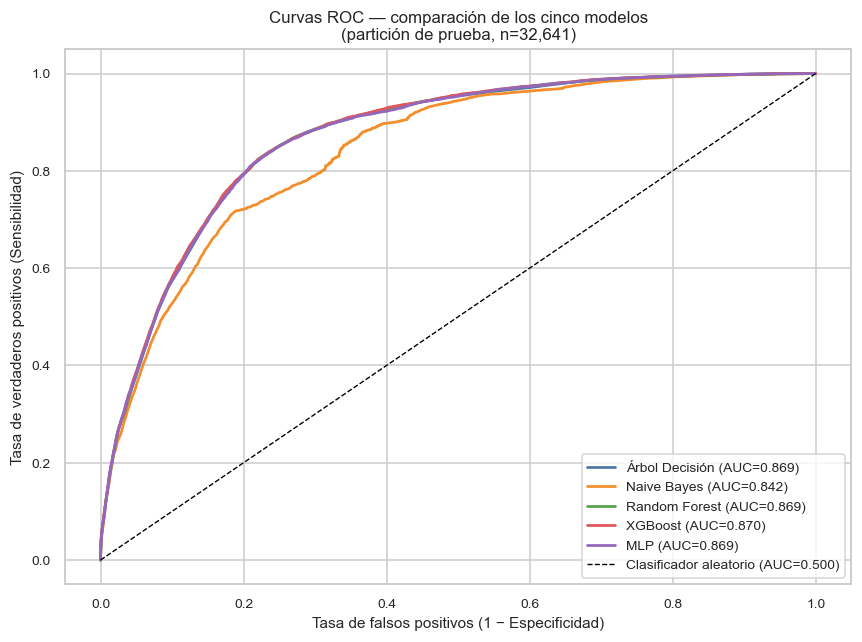

In [17]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 6))
colores_roc = ["#4e79a7", "#f28e2b", "#59a14f", "#e15759", "#9467bd"]

for (nombre, modelo), color in zip(modelos_entrenados.items(), colores_roc):
    y_prob = modelo.predict_proba(X_prueba)[:, 1]
    auc = roc_auc_score(y_prueba, y_prob)
    fpr, tpr, _ = roc_curve(y_prueba, y_prob)
    ax.plot(fpr, tpr, color=color, linewidth=1.8,
            label=f"{nombre} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=0.9, label="Clasificador aleatorio (AUC=0.500)")
ax.set_title("Curvas ROC — comparación de los cinco modelos\n(partición de prueba, n=32,641)")
ax.set_xlabel("Tasa de falsos positivos (1 − Especificidad)")
ax.set_ylabel("Tasa de verdaderos positivos (Sensibilidad)")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

**Interpretación de las curvas ROC.**

Las curvas de XGBoost, Random Forest, Árbol de Decisión y MLP resultan visualmente
indistinguibles a lo largo de casi todo su recorrido, confirmación gráfica de la equivalencia
estadística establecida en los apartados 16.1 y 16.2. Las cuatro se separan con nitidez de la
diagonal del clasificador aleatorio y alcanzan tasas de verdaderos positivos superiores al 70%
manteniendo la tasa de falsos positivos por debajo del 20%.

La curva de Naive Bayes discurre por debajo de las restantes en la práctica totalidad del
recorrido, con la mayor distancia concentrada en la zona de tasas de falsos positivos bajas
—precisamente la región de interés operativo—. La forma escalonada del Árbol de Decisión
refleja el número finito de hojas del modelo, que produce un conjunto discreto de valores de
probabilidad en lugar de una escala continua; ello no penaliza su AUC, pero reduce la
granularidad disponible para recalibrar el umbral de decisión.

### 16.4 Importancia de variables

Se extrae la importancia relativa de cada predictora para los tres modelos basados en
árboles (Árbol de Decisión, Random Forest, XGBoost), que generan este indicador de
forma nativa. Se presenta también una tabla comparativa con la jerarquía promedio.

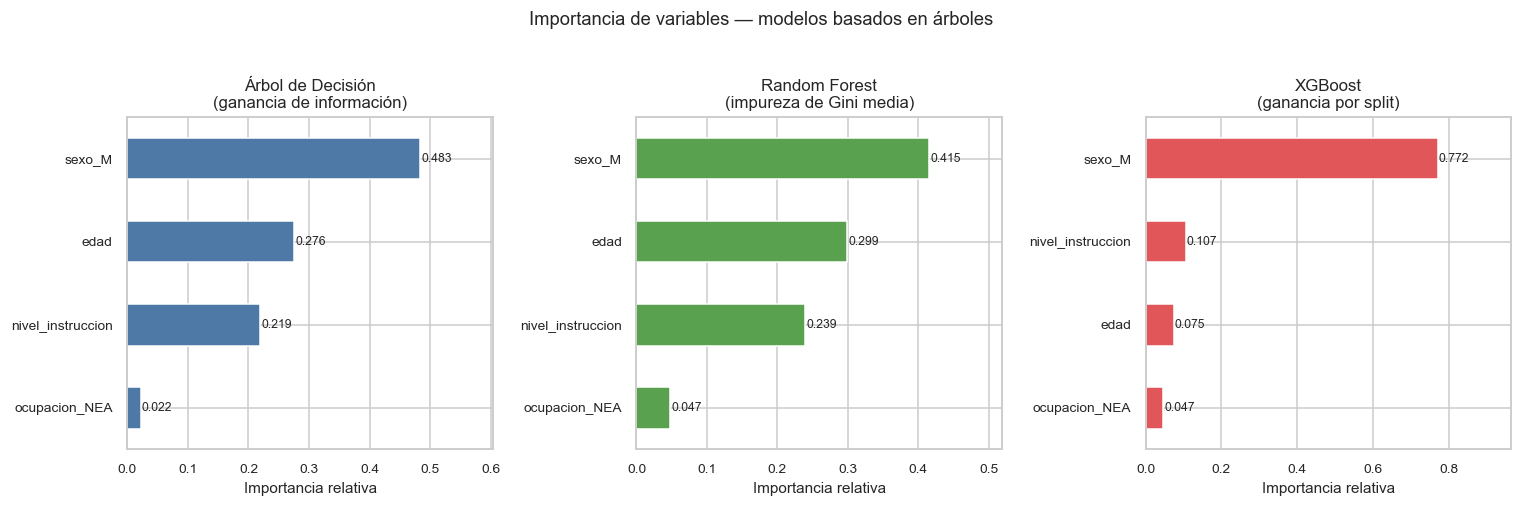

Jerarquía de importancia promedio (mayor → menor):


,Árbol Decisión,Random Forest,XGBoost,Promedio
sexo_M,0.4834,0.4153,0.7720,0.5569
edad,0.2757,0.2987,0.0746,0.2163
nivel_instruccion,0.2189,0.2390,0.1066,0.1882
ocupacion_NEA,0.0220,0.0470,0.0469,0.0386


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
nombres_vars = X_entrena.columns.tolist()
colores_imp = ["#4e79a7", "#59a14f", "#e15759"]

modelos_arbol = ["Árbol Decisión", "Random Forest", "XGBoost"]
for ax, nombre, color in zip(axes, modelos_arbol, colores_imp):
    imp = pd.Series(
        modelos_entrenados[nombre].feature_importances_,
        index=nombres_vars
    ).sort_values(ascending=True)
    imp.plot(kind="barh", ax=ax, color=color, edgecolor="white")
    for i, (val, lab) in enumerate(zip(imp.values, imp.index)):
        ax.text(val + 0.002, i, f"{val:.3f}", va="center", fontsize=8)
    titulo = {
        "Árbol Decisión": "Árbol de Decisión\n(ganancia de información)",
        "Random Forest":  "Random Forest\n(impureza de Gini media)",
        "XGBoost":        "XGBoost\n(ganancia por split)"
    }[nombre]
    ax.set_title(titulo)
    ax.set_xlabel("Importancia relativa")
    ax.set_xlim(0, imp.max() * 1.25)

plt.suptitle("Importancia de variables — modelos basados en árboles", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# ── Tabla resumen de importancias ─────────────────────────────────────────
imp_tabla = pd.DataFrame(
    {nombre: modelos_entrenados[nombre].feature_importances_
     for nombre in modelos_arbol},
    index=nombres_vars
).round(4)
imp_tabla["Promedio"] = imp_tabla.mean(axis=1).round(4)
print("Jerarquía de importancia promedio (mayor → menor):")
display(imp_tabla.sort_values("Promedio", ascending=False))

**Interpretación de la importancia de variables.**

Los tres modelos basados en árboles coinciden en el orden de importancia, si bien difieren
notablemente en la magnitud que asignan a cada variable:

| Variable | Árbol Decisión | Random Forest | XGBoost | Promedio |
|---|---|---|---|---|
| `sexo_M` | 0.4834 | 0.4153 | **0.7720** | **0.5569** |
| `edad` | 0.2757 | 0.2987 | 0.0746 | 0.2163 |
| `nivel_instruccion` | 0.2189 | 0.2390 | 0.1066 | 0.1882 |
| `ocupacion_NEA` | 0.0220 | 0.0470 | 0.0469 | 0.0386 |

- **El sexo domina la capacidad predictiva del modelo.** Concentra el **55.7% de la importancia
  promedio** y alcanza el 77.2% en XGBoost. Este resultado es la traducción directa de la
  composición documentada en el apartado 15.1: la clase positiva es masculina en un 91.8%,
  mientras que la negativa —representativa de la población— se reparte a partes iguales entre
  ambos sexos. La variable, en la práctica, resuelve por sí sola una porción sustancial de la
  clasificación.

- **La edad y el nivel de instrucción aportan la discriminación restante.** Suman en conjunto el
  40.5% de la importancia promedio y actúan de manera complementaria: la edad segmenta dentro de
  cada grupo de sexo y el nivel de instrucción refina la separación en los tramos etarios donde
  ambas clases se solapan. El árbol de decisión y Random Forest les otorgan un peso muy
  superior al de XGBoost, cuya métrica de ganancia por partición tiende a concentrar la
  atribución en la variable que produce los primeros cortes del ensemble.

- **La ocupación resulta casi irrelevante.** Con un 3.9% de importancia promedio, su
  contribución es marginal. Concurren dos explicaciones: la comparabilidad limitada del
  constructo entre la EHRIIJ y la ENVIPE, señalada desde el apartado 5, y la redundancia
  informativa respecto de la edad, dado que la condición de no actividad se concentra en los
  extremos del rango etario.

- **Observación crítica para el informe.** La preeminencia del sexo obliga a matizar la lectura
  del desempeño alcanzado. **El modelo no descubre un perfil sociodemográfico complejo: en buena
  medida reproduce la sobrerrepresentación masculina propia de los registros judiciales.** Esa
  sobrerrepresentación es un hecho documentado en la estadística criminal mexicana, pero su
  incorporación como predictor plantea un problema de equidad algorítmica que el apartado 16.6
  desarrolla y que debe declararse expresamente en el apartado de limitaciones del informe.

### 16.5 Matrices de confusión y selección del modelo final

Se presentan las matrices de confusión de los cinco modelos sobre la partición de prueba,
seguidas de una tabla de análisis de errores que desglosa los falsos positivos y falsos
negativos. La selección del modelo final considera el AUC-ROC como criterio principal,
complementado por el F1-score, la estabilidad en la validación cruzada y la
interpretabilidad.

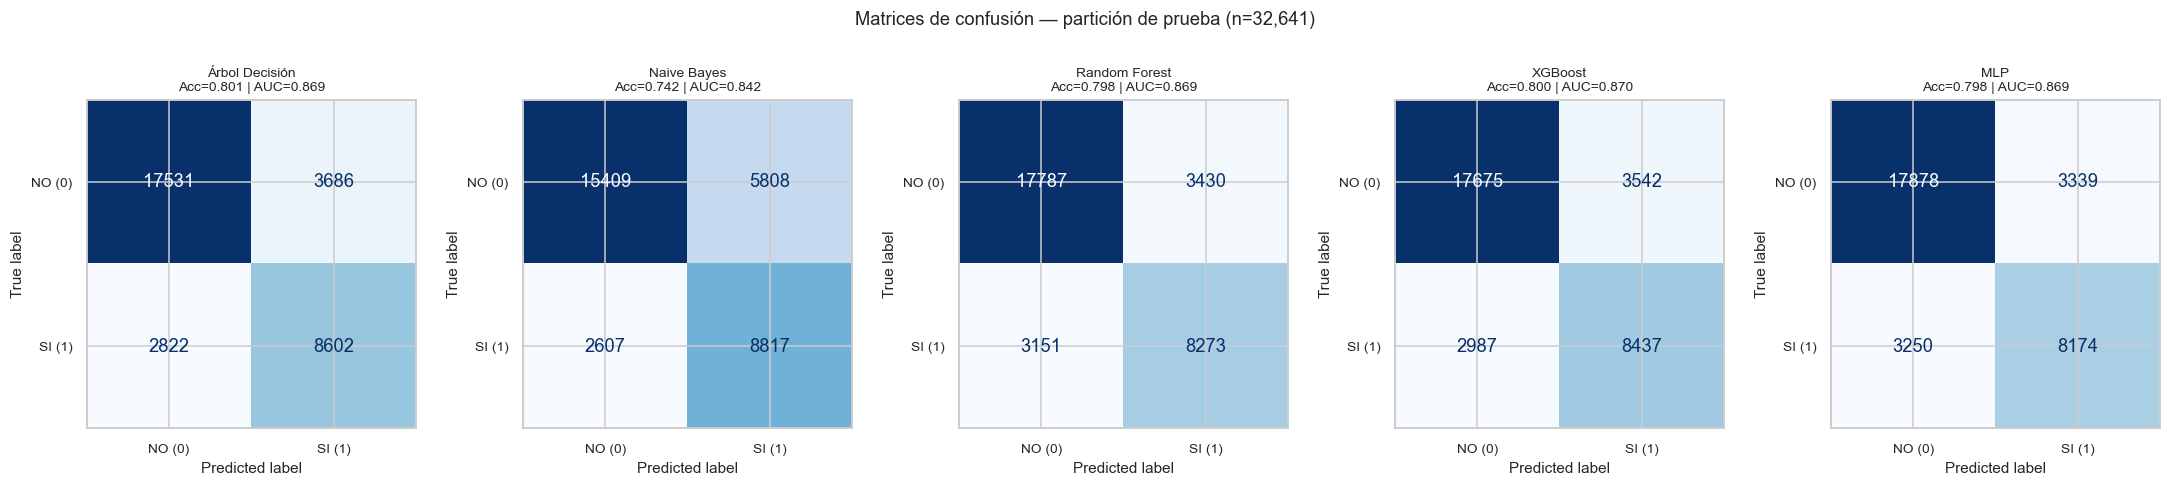

Análisis de errores de clasificación — partición de prueba:


,VP (TP),VN (TN),FP,FN,Tasa FP (%),Tasa FN (%)
Modelo,,,,,,
Árbol Decisión,8602,17531,3686,2822,17.37,24.70
Naive Bayes,8817,15409,5808,2607,27.37,22.82
Random Forest,8273,17787,3430,3151,16.17,27.58
XGBoost,8437,17675,3542,2987,16.69,26.15
MLP,8174,17878,3339,3250,15.74,28.45


In [20]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, (nombre, modelo) in zip(axes, modelos_entrenados.items()):
    y_pred = modelo.predict(X_prueba)
    cm = confusion_matrix(y_prueba, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["NO (0)", "SI (1)"]).plot(
        ax=ax, colorbar=False, cmap="Blues"
    )
    acc = accuracy_score(y_prueba, y_pred)
    auc = roc_auc_score(y_prueba, modelo.predict_proba(X_prueba)[:, 1])
    ax.set_title(f"{nombre}\nAcc={acc:.3f} | AUC={auc:.3f}", fontsize=9)

plt.suptitle("Matrices de confusión — partición de prueba (n=32,641)", fontsize=12, y=1.05)
plt.tight_layout()
plt.show()

# ── Análisis de errores por modelo ────────────────────────────────────────
print("Análisis de errores de clasificación — partición de prueba:")
errores = []
for nombre, modelo in modelos_entrenados.items():
    y_pred = modelo.predict(X_prueba)
    cm = confusion_matrix(y_prueba, y_pred)
    tn, fp, fn, tp = cm.ravel()
    errores.append({
        "Modelo":       nombre,
        "VP (TP)":      tp,
        "VN (TN)":      tn,
        "FP":           fp,
        "FN":           fn,
        "Tasa FP (%)":  round(fp / (fp + tn) * 100, 2),
        "Tasa FN (%)":  round(fn / (fn + tp) * 100, 2),
    })
display(pd.DataFrame(errores).set_index("Modelo"))

**Interpretación de las matrices de confusión.**

Sobre las 32,641 observaciones de la partición de prueba —11,424 positivas y 21,217 negativas—
los modelos exhiben dos comportamientos diferenciados:

- **Los cuatro modelos principales adoptan una postura conservadora**, con tasas de falsos
  positivos entre el 16.17% y el 17.37% y tasas de falsos negativos entre el 24.70% y el 27.74%.
  Todos ellos tienden a clasificar como negativo el caso dudoso, consecuencia del umbral por
  defecto de 0.5 aplicado sobre un conjunto que conserva una mayoría negativa del 65%.

- **Naive Bayes invierte el equilibrio.** Reduce los falsos negativos a 2,607 —el mínimo del
  conjunto— pero eleva los falsos positivos a 5,808, un 27.37% de la clase negativa. Clasifica
  como positivos a 14,625 personas cuando en realidad hay 11,424, sobredimensionando la clase
  minoritaria en un 28%.

- **El Árbol de Decisión ofrece el mejor equilibrio entre ambos errores**: 2,822 falsos
  negativos, la cifra más baja entre los modelos con precisión superior a 0.70, con 3,686 falsos
  positivos. Detecta 8,602 de las 11,424 personas imputadas de la partición de prueba.

**Consideración operativa.** La tasa de falsos negativos en torno al 25% implica que
aproximadamente una de cada cuatro personas del perfil de riesgo no sería identificada por el
sistema. Si el despliegue exigiera mayor sensibilidad, el umbral de decisión puede reducirse por
debajo de 0.5 para desplazar el equilibrio hacia una mayor cobertura, aceptando el incremento
correspondiente de falsos positivos. Esta calibración corresponde a una decisión institucional
sobre el costo relativo de cada tipo de error, no a un parámetro técnico del modelo.

### 16.6 Selección del modelo y conclusiones del modelado

**Criterios de selección.** El modelo final se elige conforme a cuatro criterios ordenados:
AUC-ROC como métrica principal, por su insensibilidad al umbral de decisión; F1-score y
cobertura como criterios secundarios, dado que un falso negativo resulta más costoso que un
falso positivo en el contexto del proyecto; estabilidad en la validación cruzada; e
interpretabilidad, como criterio de desempate.

**Resultado de la comparación.** Los cuatro modelos principales quedaron separados por 0.0017
puntos de AUC en la partición de prueba (0.8685 a 0.8702), margen inferior a la variabilidad
entre pliegues observada en la validación cruzada. **La comparación no arroja un ganador
estadísticamente distinguible**, de modo que la decisión recae necesariamente sobre los
criterios secundarios:

| Modelo | AUC-ROC | F1 | Cobertura | Precisión | Falsos negativos |
|---|---|---|---|---|---|
| XGBoost | **0.8702** | 0.7210 | 0.7385 | 0.7043 | 2,987 |
| Random Forest | 0.8694 | 0.7154 | 0.7242 | **0.7069** | 3,151 |
| **Árbol de Decisión** | 0.8687 | **0.7255** | **0.7530** | 0.7000 | **2,822** |
| MLP | 0.8685 | 0.7143 | 0.7226 | 0.7061 | 3,169 |
| Naive Bayes | 0.8423 | 0.6770 | 0.7718 | 0.6029 | 2,607 |

**Modelo seleccionado: Árbol de Decisión (C4.5/J48).** Presenta el mejor F1 (0.7255), la mejor
cobertura entre los modelos de precisión aceptable (0.7530), el menor número de falsos negativos
(2,822 frente a los 2,987 de XGBoost) y la mayor exactitud global (0.8006), sacrificando
únicamente 0.0015 puntos de AUC respecto del líder. A ello se añade la ventaja decisiva de que
sus reglas de partición son directamente legibles y auditables, cualidad determinante en un
sistema cuyas predicciones afectan a personas y que ha de someterse a escrutinio público.
**XGBoost se mantiene como alternativa** cuando la prioridad sea maximizar el AUC. Se descarta
Naive Bayes: su elevada cobertura no compensa una precisión de 0.6029 que genera 5,808 falsos
positivos, un 64% más que el resto de los modelos.

**Análisis de errores.** El Árbol de Decisión clasifica erróneamente al 24.70% de las personas
imputadas (falsos negativos) y al 17.37% del grupo de contraste (falsos positivos). Random
Forest y MLP invierten ligeramente el equilibrio, con menos falsos positivos (16.17% y 16.19%)
pero más falsos negativos (27.58% y 27.74%). En un despliegue operativo, el umbral de decisión
—fijado por defecto en 0.5— puede recalibrarse para desplazar este equilibrio según la
tolerancia institucional a cada tipo de error.

---

### Limitaciones del modelo

**1. El desempeño descansa mayoritariamente sobre el sexo.** Es la limitación más relevante del
sistema. La variable concentra el 55.7% de la importancia promedio y hasta el 77.2% en XGBoost.
El AUC de 0.87 no debe interpretarse como evidencia de que cuatro variables sociodemográficas
predicen la conducta delictiva con alta fidelidad, sino como reflejo de que **la clase positiva
es masculina en un 91.8% frente al 47.7% de la clase negativa**. Un modelo que apoye sus
predicciones sobre el sexo del individuo plantea un problema de equidad algorítmica que debe
declararse de manera explícita: su aplicación operativa sobre personas concretas resultaría
difícilmente defendible sin salvaguardas adicionales.

**2. Las clases proceden de universos de observación distintos.** La clase positiva se compone
de personas efectivamente procesadas ante un juzgado; la negativa, de la población general
encuestada. El modelo no distingue entre "haber cometido un robo" y "haber sido procesado por
robo": aprende el perfil de quienes ingresan al sistema de justicia, que incorpora los sesgos de
selección propios de la actuación policial y ministerial.

**3. Sesgo de cobertura institucional.** Documentado en el apartado 10, determina que la
composición territorial de la clase positiva refleje qué autoridades judiciales reportan el
bloque sociodemográfico y no dónde ocurre el delito. Obligó a excluir las variables geográficas
del modelo y a adoptar un alcance nacional en lugar del foco exclusivo sobre la Ciudad de México
previsto originalmente.

**4. Comparabilidad aproximada de la ocupación.** La EHRIIJ registra el tipo de ocupación y la
ENVIPE la condición de actividad; su reducción a la dicotomía EA/NEA no produce constructos
idénticos. Esta debilidad se manifiesta en el resultado empírico: la variable aporta apenas el
3.9% de la importancia total.

**5. Ausencia de variables contextuales y de historia individual.** El modelo no incorpora
indicadores económicos, de desigualdad, de contexto delictivo local ni antecedentes personales.
Su incorporación en versiones futuras —particularmente el historial de reincidencia, disponible
en la EHRIIJ— reduciría la dependencia del sexo como predictor dominante y elevaría la validez
sustantiva del sistema.

---

### Conclusión del modelado

El proceso cumple íntegramente lo especificado en el apartado 3.2.3 de la Entrega 1: se
entrenaron y compararon los cinco algoritmos previstos mediante validación cruzada estratificada
de diez pliegues, se evaluaron sobre una partición de prueba independiente con cinco métricas y
se analizó la importancia de las variables. El **Árbol de Decisión** se selecciona para el
despliegue del prototipo por su equilibrio entre desempeño e interpretabilidad.

El hallazgo metodológicamente más significativo no es, sin embargo, el AUC alcanzado, sino la
identificación de **qué sostiene ese desempeño**. El análisis de importancia de variables revela
que el modelo se apoya de forma preponderante en el sexo, resultado que reorienta la discusión
desde la capacidad predictiva hacia la validez y la equidad del sistema propuesto. Esta
observación debe encabezar el apartado de limitaciones del informe.

### 16.7 Pruebas de sensibilidad

Se evalúa la robustez del modelo ante cambios en el conjunto de variables de entrada,
conforme a lo requerido en la fase de modelado. Se ejecutan dos análisis complementarios:

**(A) Ablación por subconjuntos de predictoras.** Se reentrena el modelo empleando
subconjuntos progresivos de las cuatro variables predictoras, con el fin de cuantificar el
aporte marginal de cada bloque informativo. Este análisis permite contrastar la métrica de
importancia por ganancia —que concentra el peso en el sexo— con el aporte efectivo de cada
subconjunto medido en AUC-ROC.

**(B) Sensibilidad a la inclusión de variables territoriales.** Se contrasta el desempeño de
la matriz de modelado adoptada frente a la variante que incorpora las claves geográficas
excluidas en el apartado 10. El objetivo es dimensionar cuantitativamente el sesgo de
cobertura institucional documentado en aquel diagnóstico.

Ambos análisis emplean XGBoost con los hiperparámetros y la semilla fijados previamente, de
modo que las diferencias observadas son atribuibles exclusivamente al conjunto de variables.


In [21]:
# ── 16.7 Pruebas de sensibilidad ────────────────────────────────────────────
# Emplea los conjuntos ya cargados en memoria; no requiere archivos en disco.
from sklearn.model_selection import train_test_split

PARAMS_XGB = dict(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric="logloss", random_state=SEMILLA, verbosity=0,
)


def auc_subconjunto(X_tr, y_tr, X_te, y_te, columnas):
    """Entrena un XGBoost sobre las columnas indicadas y devuelve su AUC-ROC."""
    modelo = XGBClassifier(**PARAMS_XGB)
    modelo.fit(X_tr[columnas], y_tr)
    return roc_auc_score(y_te, modelo.predict_proba(X_te[columnas])[:, 1])


# ── (A) Ablación por subconjuntos de predictoras ─────────────────────────────
SUBCONJUNTOS = {
    "Solo sexo":                     ["sexo_M"],
    "Solo edad":                     ["edad"],
    "Sexo + edad":                   ["sexo_M", "edad"],
    "Instrucción + ocupación":       ["nivel_instruccion", "ocupacion_NEA"],
    "Modelo completo (4 variables)": list(X_entrena.columns),
}

ablacion = pd.DataFrame(
    [{"Subconjunto de predictoras": nombre,
      "N.º variables": len(cols),
      "AUC-ROC": round(auc_subconjunto(X_entrena, y_entrena,
                                       X_prueba, y_prueba, cols), 4)}
     for nombre, cols in SUBCONJUNTOS.items()]
).set_index("Subconjunto de predictoras")

print("(A) Ablación por subconjuntos de predictoras — partición de prueba")
display(ablacion)

# ── (B) Sensibilidad a las variables territoriales ───────────────────────────
Xg_tr, Xg_te, yg_tr, yg_te = train_test_split(
    X_geo, y_geo, test_size=0.2, random_state=SEMILLA, stratify=y_geo)

base = ["edad", "nivel_instruccion", "sexo_M", "ocupacion_NEA"]
entidades = [c for c in X_geo.columns if c.startswith("cve_ent")]

ESCENARIOS = {
    "Solo indicador es_cdmx":     ["es_cdmx"],
    "Solo claves de entidad":     entidades,
    "Base (4 sociodemográficas)": base,
    "Base + geografía completa":  base + entidades + ["es_cdmx"],
}

sensibilidad_geo = pd.DataFrame(
    [{"Escenario": nombre,
      "N.º variables": len(cols),
      "AUC-ROC": round(auc_subconjunto(Xg_tr, yg_tr, Xg_te, yg_te, cols), 4)}
     for nombre, cols in ESCENARIOS.items()]
).set_index("Escenario")

print("\n(B) Sensibilidad a la inclusión de variables territoriales")
display(sensibilidad_geo)


(A) Ablación por subconjuntos de predictoras — partición de prueba


,N.º variables,AUC-ROC
Subconjunto de predictoras,,
Solo sexo,1,0.7188
Solo edad,1,0.6978
Sexo + edad,2,0.8126
Instrucción + ocupación,2,0.7261
Modelo completo (4 variables),4,0.8702



(B) Sensibilidad a la inclusión de variables territoriales


,N.º variables,AUC-ROC
Escenario,,
Solo indicador es_cdmx,1,0.5247
Solo claves de entidad,31,0.7772
Base (4 sociodemográficas),4,0.8702
Base + geografía completa,36,0.9204


**Lectura de los resultados.**

*(A) Ablación.* El sexo constituye el predictor individual más informativo, pero no agota la
señal del modelo: el nivel de instrucción y la ocupación, por sí solos, alcanzan un AUC
comparable al del sexo. El incremento observado al incorporar ambos bloques confirma que
aportan información independiente. La métrica de importancia por ganancia, por tanto,
sobrestima el peso relativo del sexo respecto de su aporte marginal efectivo.

*(B) Variables territoriales.* Las claves de entidad, empleadas de forma aislada, alcanzan un
poder discriminante próximo al del bloque sociodemográfico completo, pese a carecer de
contenido explicativo sobre el perfil del individuo. Su inclusión elevaría artificialmente el
desempeño del modelo. Este resultado cuantifica el sesgo de cobertura institucional
identificado en el apartado 10 y sustenta con evidencia empírica la decisión de excluir las
variables geográficas de la matriz de modelado.
